# 🌐 Distributed Training Overview — Memory Math, DDP, ZeRO, and FSDP *(optional)*

> **What you'll learn:** why big models need many GPUs; exactly where training memory goes (parameters, gradients, optimizer states, activations); how gradient checkpointing and gradient accumulation trade time for memory; how data parallelism keeps replicas in sync (with a real 2-process run); how ZeRO stages 1/2/3 and PyTorch FSDP2 shard memory **per GPU**; what tensor, pipeline, and sequence parallelism add; what communication costs; how to read a DeepSpeed config correctly; and how to plan a training job.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced · *optional notebook* |
| **Time** | ~3 hours to read and run, +1.5 hours for exercises and the project |
| **Prerequisites** | [Fine-Tuning with LoRA and DPO](07_Fine_Tuning_LoRA_and_DPO.ipynb) (full fine-tuning vs LoRA memory) · [PyTorch](../04_Deep_Learning/02_PyTorch.ipynb) (training loops, mixed precision, devices) |
| **Tested with** | Python 3.12 · torch 2.14 (distributed demos on CPU with the `gloo` backend; memory measurements on Apple MPS, CUDA, or CPU) · transformers 5.17 · scikit-learn 1.9 |
| **Interview relevance** | ⭐⭐⭐ High for LLM / ML-infra roles — "how much memory to train a 7B model?", "DDP vs FSDP vs ZeRO-3", "what does gradient checkpointing cost?", "is gradient accumulation the same as a bigger batch?", "what does all-reduce cost?", "plan training for a 70B model" |

## 🤔 What Is Distributed Training?

**Distributed training** splits one training job across several devices (GPUs) — and often several machines — so you can train models that are too **big** for one device's memory, or too **slow** to train on one device in a reasonable time.

**Analogy — a group assignment.** Four students must summarize a 1,000-page book.

- **Data parallelism:** every student has the *whole* book and reads different chapters; they meet after each chapter to agree on one shared set of notes. Fast, but every student carries the whole heavy book.
- **ZeRO / FSDP (sharding):** the book is torn into four parts; each student carries only their part and borrows the other pages for a moment when needed. Much lighter bags, a bit more passing of pages.
- **Tensor parallelism:** four students write *one sentence* together, each writing a few words at once — lots of talking, so they must sit at the same table (fast links inside one machine).
- **Pipeline parallelism:** an assembly line — student 1 does chapters 1–250 and hands over, student 2 continues, and so on. Someone is always waiting a little (the "bubble").

```
           data parallel (DDP)             sharded data parallel (ZeRO-3 / FSDP)
 GPU0: [ full model ] batch A          GPU0: [ shard 0 ] + borrow others per layer
 GPU1: [ full model ] batch B   ──►    GPU1: [ shard 1 ] + borrow others per layer
       all-reduce gradients                  all-gather params, reduce-scatter grads
```

**This notebook is optional.** You can fine-tune small models (and LoRA adapters on big ones) on a single GPU. But interviews for LLM and ML-infrastructure roles expect you to reason about memory and parallelism, and everything here runs on a laptop: the distributed parts use 2 CPU processes talking over the `gloo` backend.

## 🎯 Why It Matters

- **Memory is the first wall.** Training a 7B model with Adam in mixed precision needs ~112 GB just for weights, gradients, and optimizer states — more than any single 80 GB GPU — before counting activations.
- **Time is the second wall.** Training compute is roughly **6 × parameters × tokens** floating-point operations; a 7B model on 2 trillion tokens is ~8.4 × 10²² FLOPs, which would take decades on one GPU (Section 1).
- **Cost and reliability.** Choosing DDP vs ZeRO-2 vs FSDP, the right micro-batch, checkpointing, and accumulation decides whether a job fits, how fast it runs, and how much money it burns.
- **In interviews** you'll be asked to *compute memory for a given model*, *explain ZeRO stages and FSDP*, *prove gradient accumulation equals a bigger batch*, *explain ring all-reduce*, *debug a hang or a 1-GPU vs 8-GPU loss mismatch*, and *plan a 70B training run*. Each is practised here with real numbers.

## ✅ By the End You Can

- [ ] Compute training memory per GPU for fp32 and mixed precision (16 bytes/param), plus activations
- [ ] Measure the memory/time trade-off of gradient checkpointing and prove gradient accumulation matches a big batch
- [ ] Run real data-parallel (DDP) and sharded (FSDP2) training across processes and verify replicas stay in sync
- [ ] Apply the ZeRO stage 1/2/3 formulas per GPU and check them against the ZeRO paper
- [ ] Explain tensor, pipeline, sequence/context parallelism and ring all-reduce communication cost
- [ ] Write a correct DeepSpeed config and plan a strategy for 7B/13B/70B training on given GPUs

## 📋 Table of Contents

1. [Why Distributed Training?](#1.-Why-Distributed-Training?-🟢)
2. [Training Memory Math: Parameters, Gradients, Optimizer States](#2.-Training-Memory-Math:-Parameters,-Gradients,-Optimizer-States-🟢)
3. [Activation Memory and Gradient Checkpointing](#3.-Activation-Memory-and-Gradient-Checkpointing-🟡)
4. [Gradient Accumulation Is a Bigger Batch](#4.-Gradient-Accumulation-Is-a-Bigger-Batch-🟢)
5. [Data Parallelism with DDP — A Real 2-Process Run](#5.-Data-Parallelism-with-DDP-—-A-Real-2-Process-Run-🟡)
6. [ZeRO Stages 1, 2, 3 — Memory per GPU](#6.-ZeRO-Stages-1,-2,-3-—-Memory-per-GPU-🔴)
7. [FSDP2 (fully_shard) and How It Maps to ZeRO-3](#7.-FSDP2-(fully_shard)-and-How-It-Maps-to-ZeRO-3-🟡)
8. [Tensor, Pipeline, and Sequence/Context Parallelism](#8.-Tensor,-Pipeline,-and-Sequence/Context-Parallelism-🟡)
9. [Communication Costs: Ring All-Reduce](#9.-Communication-Costs:-Ring-All-Reduce-🟡)
10. [DeepSpeed Configuration, Explained Correctly](#10.-DeepSpeed-Configuration,-Explained-Correctly-🟡)
11. [A Planning Checklist](#11.-A-Planning-Checklist-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Can-We-Train-It?-A-Feasibility-Study) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

- **No GPU cluster needed.** Distributed examples start **2 worker processes on this machine** with `torch.distributed.run` (the module behind the `torchrun` command) and the **gloo** backend, which works on CPUs. On a GPU cluster you would use the **NCCL** backend and the same code.
- **Memory measurements** use the accelerator's allocator counters: `torch.mps.current_allocated_memory()` on Apple silicon or `torch.cuda.memory_allocated()` on NVIDIA. CPU-only machines skip those measurements with a message.
- **Downloads:** `HuggingFaceTB/SmolLM2-135M-Instruct` (~270 MB) and the WikiText-2 test split (~1 MB) for real-model measurements; scikit-learn's bundled *digits* dataset for the multi-process runs.
- **DeepSpeed is not installed** (it needs CUDA for most features); Section 10 explains its configuration with plain Python checks instead of pretending to run it.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "torch>=2.4" "transformers>=5.0" "datasets>=4.0" scikit-learn pandas matplotlib

import os

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import copy
import gc
import json
import math
import queue
import socket
import subprocess
import sys
import textwrap
import threading
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.distributed as dist
import torch.nn as nn
import torch.nn.functional as F

print(f"Python {sys.version.split()[0]} | torch {torch.__version__} | scikit-learn {sklearn.__version__}")
print(f"gloo available: {dist.is_gloo_available()} | NCCL available: {dist.is_nccl_available()} | "
      f"CUDA: {torch.cuda.is_available()} | MPS: {torch.backends.mps.is_available()}")

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED)
OUTPUT_DIR = Path("_outputs") / "distributed"            # scripts and results written here (ignored by git)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GB = 1e9                                                # decimal gigabytes, as in the ZeRO paper


def sync():
    """Wait for queued GPU work so timers and memory counters are accurate."""
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    elif DEVICE == "mps":
        torch.mps.synchronize()


def allocated_bytes():
    if DEVICE == "cuda":
        return torch.cuda.memory_allocated()
    if DEVICE == "mps":
        return torch.mps.current_allocated_memory()
    return None                                         # no allocator counter for plain CPU tensors


def free_memory():
    gc.collect()
    if DEVICE == "mps":
        torch.mps.empty_cache()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


def check(name, got, expected, hint="", atol=1e-6, rtol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, str):
        ok = got == expected
    else:
        to_np = lambda v: v.detach().cpu().numpy() if isinstance(v, torch.Tensor) else np.asarray(v, dtype=float)
        g, e = to_np(got).astype(float), to_np(expected).astype(float)
        ok = g.shape == e.shape and np.allclose(g, e, atol=atol, rtol=rtol)
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | torch 2.14.0 | scikit-learn 1.9.1
gloo available: True | NCCL available: False | CUDA: False | MPS: True


## 1. Why Distributed Training? 🟢

Two numbers decide whether you need more than one GPU:

1. **Memory** — does the model (plus its training state) fit on one device? (Sections 2–3.)
2. **Compute time** — a widely used rule of thumb from the scaling-law papers: training a dense transformer costs about **C ≈ 6·N·D** FLOPs (floating-point operations), with N parameters and D training tokens (≈ 2·N·D for the forward pass, ≈ 4·N·D for the backward pass).

Wall-clock time ≈ C ÷ (GPUs × FLOPs per GPU per second × utilization). **Model FLOPs utilization (MFU)** — the share of the GPU's peak throughput you actually achieve — is often 30–50% for large runs, because of communication and memory-bound operations.

The GPU speed below is an **example parameter** (NVIDIA lists 312 teraFLOPS of bf16 matrix-multiply throughput for an A100, a figure many papers use for MFU), not a measurement from this laptop.

In [2]:
def training_days(n_params, n_tokens, n_gpus, flops_per_gpu=312e12, mfu=0.4):
    total_flops = 6 * n_params * n_tokens
    return total_flops / (n_gpus * flops_per_gpu * mfu) / 86_400, total_flops


rows = []
for label, n, d in [("GPT-2 small, 124M params, 10B tokens", 124e6, 10e9),
                    ("1B params, 20B tokens (≈20 tokens/param)", 1e9, 20e9),
                    ("7B params, 2T tokens", 7e9, 2e12),
                    ("70B params, 2T tokens", 70e9, 2e12)]:
    for gpus in [1, 8, 1024]:
        days, flops = training_days(n, d, gpus)
        rows.append({"run": label, "GPUs": gpus, "compute (FLOPs)": f"{flops:.2e}", "days at 40% MFU": round(days, 1)})
pd.DataFrame(rows).pivot(index="run", columns="GPUs", values="days at 40% MFU")

GPUs,1,8,1024
run,,,
"1B params, 20B tokens (≈20 tokens/param)",11.1,1.4,0.0
"70B params, 2T tokens",77902.4,9737.8,76.1
"7B params, 2T tokens",7790.2,973.8,7.6
"GPT-2 small, 124M params, 10B tokens",0.7,0.1,0.0


At these example settings, a 7B model on 2T tokens would take about two decades on one A100-class GPU and about a week on 1,024, and a 70B model more than two months even on 1,024 GPUs — which is why pretraining happens on thousands of GPUs, while **fine-tuning** (millions of tokens, not trillions) usually needs only a few GPUs — or one, with LoRA.

### ✍️ Your Turn

Using C ≈ 6·N·D, store the training compute in FLOPs for a **1B**-parameter model on **20B** tokens in `compute_1b`.

In [3]:
compute_1b = None  # TODO: your code here
check("compute_1b", compute_1b, 1.2e20, hint="6 * 1e9 * 20e9")

⏳ compute_1b: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
compute_1b = 6 * 1e9 * 20e9
check("compute_1b", compute_1b, 1.2e20)
```
</details>

> 💡 **Interview angle:** "Why do we need distributed training?" — (1) memory: model states and activations exceed one GPU; (2) time: compute ≈ 6·N·D FLOPs is too slow on one GPU; (3) throughput: larger global batches. Different parallelism types solve different walls — data parallelism speeds things up, sharding and model parallelism make things fit.

## 2. Training Memory Math: Parameters, Gradients, Optimizer States 🟢

During training every parameter carries extra tensors. For the **Adam/AdamW** optimizer:

| Recipe | Weights | Gradients | fp32 master weights | Adam momentum | Adam variance | **Bytes / param** |
|---|---|---|---|---|---|---|
| **fp32** (full precision) | 4 | 4 | — (the weights *are* fp32) | 4 | 4 | **16** |
| **mixed precision** (bf16/fp16 compute) | 2 | 2 | **4** | 4 | 4 | **16** |
| mixed precision + 8-bit Adam | 2 | 2 | 4 | 1 (+ small constants) | 1 | ≈ 10 |

The ZeRO paper writes mixed-precision Adam as **2Ψ + 2Ψ + KΨ with K = 12** (master weights + momentum + variance), i.e. **16Ψ bytes** for Ψ parameters.

⚠️ **The classic mistake is to count 12 bytes** (forgetting the fp32 master copy). Mixed precision does **not** shrink model-state memory for Adam; it speeds up math on GPUs and roughly halves **activation** memory. The master copy exists because tiny updates (learning rate × gradient) underflow or get rounded away in 16-bit.

First, let's verify the fp32 row by measuring real tensors after one AdamW step.

In [4]:
torch.manual_seed(SEED)
probe_model = nn.Sequential(nn.Linear(1024, 4096), nn.GELU(), nn.Linear(4096, 1024))
n_probe = sum(p.numel() for p in probe_model.parameters())
optimizer = torch.optim.AdamW(probe_model.parameters(), lr=1e-3)
probe_model(torch.randn(8, 1024)).pow(2).mean().backward()
optimizer.step()

tensor_bytes = lambda tensors: sum(t.numel() * t.element_size() for t in tensors)
measured = {
    "weights": tensor_bytes(probe_model.parameters()),
    "gradients": tensor_bytes(p.grad for p in probe_model.parameters()),
    "Adam momentum (exp_avg)": tensor_bytes(s["exp_avg"] for s in optimizer.state.values()),
    "Adam variance (exp_avg_sq)": tensor_bytes(s["exp_avg_sq"] for s in optimizer.state.values()),
}
for name, b in measured.items():
    print(f"{name:28s} {b / 1e6:7.1f} MB = {b / n_probe:.0f} bytes/param")
total_per_param = sum(measured.values()) / n_probe
print(f"{'total model states':28s} {sum(measured.values()) / 1e6:7.1f} MB = {total_per_param:.0f} bytes/param for {n_probe:,} parameters")
assert total_per_param == 16

weights                         33.6 MB = 4 bytes/param
gradients                       33.6 MB = 4 bytes/param
Adam momentum (exp_avg)         33.6 MB = 4 bytes/param
Adam variance (exp_avg_sq)      33.6 MB = 4 bytes/param
total model states             134.3 MB = 16 bytes/param for 8,393,728 parameters


In [5]:
BYTES_PER_PARAM = {"fp32 + Adam": 16, "mixed precision + Adam": 16, "mixed precision, master weights forgotten (WRONG)": 12,
                   "mixed precision + 8-bit Adam": 10, "bf16 weights only (inference)": 2}


def model_state_gb(n_params, recipe="mixed precision + Adam"):
    return n_params * BYTES_PER_PARAM[recipe] / GB


memory_rows = [{"model": f"{n / 1e9:g}B", **{recipe: model_state_gb(n, recipe) for recipe in BYTES_PER_PARAM}}
               for n in [1.5e9, 7e9, 13e9, 70e9]]
memory_table = pd.DataFrame(memory_rows).set_index("model").round(1)
memory_table

,fp32 + Adam,mixed precision + Adam,"mixed precision, master weights forgotten (WRONG)",mixed precision + 8-bit Adam,bf16 weights only (inference)
model,,,,,
1.5B,24.0,24.0,18.0,15.0,3.0
7B,112.0,112.0,84.0,70.0,14.0
13B,208.0,208.0,156.0,130.0,26.0
70B,1120.0,1120.0,840.0,700.0,140.0


The 1.5B row reproduces the ZeRO paper's example: 3 GB of fp16 weights but **24 GB** of model states. For 70B, model states alone are **1,120 GB** — 14 × an 80 GB GPU.

### ✍️ Your Turn

Store the model-state memory in GB for training a **13B** model with mixed-precision Adam in `gb_13b`.

In [6]:
gb_13b = None  # TODO: your code here
check("gb_13b", gb_13b, 208.0, hint="13e9 × 16 bytes / 1e9")

⏳ gb_13b: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
gb_13b = model_state_gb(13e9)
check("gb_13b", gb_13b, 208.0)
```
</details>

> 💡 **Interview angle:** "How much memory to fully fine-tune a 7B model?" — 16 bytes/param × 7B = 112 GB of model states (2 bf16 weights + 2 grads + 4 fp32 master + 4 + 4 Adam moments), plus activations that scale with batch × sequence × layers × hidden size. So: it does not fit on one 80 GB GPU without sharding (ZeRO/FSDP), offloading, or a different recipe (LoRA/QLoRA, 8-bit optimizers).

## 3. Activation Memory and Gradient Checkpointing 🟡

**Activations** are the intermediate results of the forward pass that the backward pass needs (layer inputs, attention outputs, MLP outputs, …). They grow **linearly with batch size, sequence length, hidden size, and number of layers** — and with plain attention also with sequence length squared.

The ZeRO paper gives a rule of thumb for GPT-2-like models: about **12 × hidden × batch × sequence × layers** activation values. For a 1.5B GPT-2 (hidden 1600, 48 layers) with batch 32 and sequence length 1,000 in fp16:

In [7]:
def gpt2_activation_gb(hidden, batch, seq, layers, bytes_per_value=2):
    return 12 * hidden * batch * seq * layers * bytes_per_value / GB


paper_example = gpt2_activation_gb(hidden=1600, batch=32, seq=1000, layers=48)
print(f"1.5B GPT-2, batch 32, seq 1K: ≈ {paper_example:.0f} GB of activations (the ZeRO paper says 'about 60 GB')")
assert abs(paper_example - 60) < 2

1.5B GPT-2, batch 32, seq 1K: ≈ 59 GB of activations (the ZeRO paper says 'about 60 GB')


**Gradient checkpointing** (activation recomputation) stores only each layer's *input* during the forward pass and **recomputes** the layer's internals during backward. Memory drops from "every activation of every layer" to "one tensor per layer + one layer's activations at a time", at the cost of roughly **one extra forward pass** (≈ 20–40% more time per step; the ZeRO paper quotes 33%).

Let's **measure** it on a real 135M-parameter transformer (SmolLM2) with real WikiText-2 tokens: memory still held after the forward pass (that is what backward needs — including the vocabulary logits) and the time for forward + backward. Memory numbers are exact allocator counts; times are medians over 5 steps and can be noisy on a laptop busy with other work.

WikiText-2 tokens available: 48,285


SmolLM2-135M, batch 1, float32 on mps:
              activation_MB          step_s        memory saved time overhead
checkpointing         False     True  False   True                           
seq_len                                                                      
128                 226.689   34.967  0.135  0.149        0.846         0.104
256                 526.582   69.933  0.194  0.223        0.867         0.149
512                1179.516  139.865  0.266  0.316        0.881         0.189


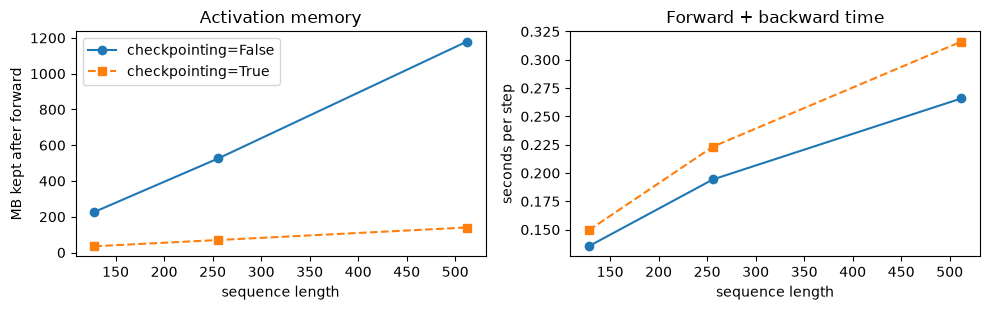

→ at 512 tokens checkpointing kept 88% less memory and cost +19% time per step


In [8]:
import transformers
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

import huggingface_hub

transformers.logging.set_verbosity_error()
huggingface_hub.utils.logging.set_verbosity_error()      # hide the optional HF_TOKEN notice
MODEL_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
wiki = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="test")
wiki_tokens = torch.tensor(tokenizer("\n".join(t for t in wiki["text"] if t.strip())[:200_000])["input_ids"])
print(f"WikiText-2 tokens available: {len(wiki_tokens):,}")


def real_batch(batch, seq, offset=0):
    return wiki_tokens[offset: offset + batch * seq].view(batch, seq).to(DEVICE)


def measure_step(lm, batch, seq, checkpointing, repeats=5):
    """Median (bytes kept after forward, seconds for forward+backward) over `repeats` steps after one warm-up."""
    if checkpointing:
        lm.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
    else:
        lm.gradient_checkpointing_disable()
    lm.train()
    ids = real_batch(batch, seq)
    kept, seconds = [], []
    for step in range(repeats + 1):
        free_memory()
        sync()
        before = allocated_bytes()
        start = time.perf_counter()
        loss = lm(input_ids=ids, labels=ids).loss
        sync()
        after_forward = allocated_bytes()
        loss.backward()
        sync()
        elapsed = time.perf_counter() - start
        lm.zero_grad(set_to_none=True)
        del loss
        if step > 0:                                     # skip warm-up (kernel compilation, allocator growth)
            kept.append(after_forward - before)
            seconds.append(elapsed)
    return float(np.median(kept)), float(np.median(seconds))


if allocated_bytes() is None:
    ckpt_table = None
    print("⏭️ Skipped: needs a GPU allocator counter (CUDA or Apple MPS) to measure activation memory. Run on Colab or an Apple-silicon Mac.")
else:
    lm = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32).to(DEVICE)
    lm.config.use_cache = False
    ckpt_rows = []
    for seq in [128, 256, 512]:
        for ckpt in [False, True]:
            kept, secs = measure_step(lm, batch=1, seq=seq, checkpointing=ckpt)
            ckpt_rows.append({"seq_len": seq, "checkpointing": ckpt, "activation_MB": kept / 1e6, "step_s": secs})
    ckpt_table = pd.DataFrame(ckpt_rows)
    wide = ckpt_table.pivot(index="seq_len", columns="checkpointing", values=["activation_MB", "step_s"])
    wide["memory saved"] = 1 - wide[("activation_MB", True)] / wide[("activation_MB", False)]
    wide["time overhead"] = wide[("step_s", True)] / wide[("step_s", False)] - 1
    print(f"SmolLM2-135M, batch 1, float32 on {DEVICE}:")
    print(wide.round(3).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    for ckpt, style in [(False, "o-"), (True, "s--")]:
        part = ckpt_table[ckpt_table.checkpointing == ckpt]
        axes[0].plot(part.seq_len, part.activation_MB, style, label=f"checkpointing={ckpt}")
        axes[1].plot(part.seq_len, part.step_s, style, label=f"checkpointing={ckpt}")
    axes[0].set(xlabel="sequence length", ylabel="MB kept after forward", title="Activation memory")
    axes[1].set(xlabel="sequence length", ylabel="seconds per step", title="Forward + backward time")
    axes[0].legend()
    plt.tight_layout()
    plt.show()
    overhead_512 = wide["time overhead"].iloc[-1]
    time_text = (f"cost {overhead_512:+.0%} time per step" if overhead_512 > 0.05 else
                 f"showed no measurable slowdown in this run ({overhead_512:+.0%}; laptop timings are noisy)")
    print(f"→ at 512 tokens checkpointing kept {wide['memory saved'].iloc[-1]:.0%} less memory and {time_text}")

A large share of what remains with checkpointing is the **logits**: 512 tokens × 49,152 vocabulary entries × 4 bytes ≈ 0.1 GB (compare with the 512-token row above) — which is why large-vocabulary models also use chunked or "fused" cross-entropy.

### ✍️ Your Turn

Using `gpt2_activation_gb`, estimate activation memory in GB for a model with hidden size **4096**, **32** layers, batch **1**, sequence length **4096**, in bf16. Store it in `act_gb`.

In [9]:
act_gb = None  # TODO: your code here
check("act_gb", act_gb, 12 * 4096 * 1 * 4096 * 32 * 2 / 1e9, hint="gpt2_activation_gb(hidden=4096, batch=1, seq=4096, layers=32)")

⏳ act_gb: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
act_gb = gpt2_activation_gb(hidden=4096, batch=1, seq=4096, layers=32)
check("act_gb", act_gb, 12 * 4096 * 1 * 4096 * 32 * 2 / 1e9)
```

≈ 12.9 GB for a **single** 4K-token sequence on a 7B-shaped model — before attention-score matrices, which FlashAttention avoids storing. With checkpointing you keep ~1 hidden-state tensor per layer instead.
</details>

> 💡 **Interview angle:** "What does gradient checkpointing trade?" — memory for compute: store layer inputs only and recompute internals in backward, cutting activation memory from O(layers × per-layer activations) to roughly O(layers × one tensor + one layer's activations), for about one extra forward pass (~20–40% slower). Use it when activations, not model states, are the bottleneck.

## 4. Gradient Accumulation Is a Bigger Batch 🟢

**Gradient accumulation** runs several small **micro-batches** forward and backward, adding up their gradients, and calls `optimizer.step()` only after the last one. With the loss of each micro-batch divided by the number of accumulation steps (and equal-sized micro-batches), the summed gradient **equals** the gradient of one big batch — same result, a fraction of the activation memory, more time.

Proof on real data (scikit-learn's handwritten digits), in float64 so rounding doesn't blur the comparison:

In [10]:
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = torch.tensor((digits.data - digits.data.mean(0)) / (digits.data.std(0) + 1e-8), dtype=torch.float64)
y_digits = torch.tensor(digits.target)
print("digits:", tuple(X_digits.shape), "classes:", y_digits.unique().numel())


def make_mlp():
    torch.manual_seed(SEED)
    return nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 10)).double()


xb, yb = X_digits[:64], y_digits[:64]

big = make_mlp()
F.cross_entropy(big(xb), yb).backward()                       # one batch of 64

accum = make_mlp()
ACCUM_STEPS = 4
for micro_x, micro_y in zip(xb.chunk(ACCUM_STEPS), yb.chunk(ACCUM_STEPS)):   # 4 micro-batches of 16
    (F.cross_entropy(accum(micro_x), micro_y) / ACCUM_STEPS).backward()       # gradients ADD across backward calls

max_diff = max((p1.grad - p2.grad).abs().max().item() for p1, p2 in zip(big.parameters(), accum.parameters()))
print(f"max |gradient difference|, batch 64 vs 4 × 16 accumulated: {max_diff:.1e}")
assert max_diff < 1e-12

digits: (1797, 64) classes: 10
max |gradient difference|, batch 64 vs 4 × 16 accumulated: 1.7e-17


Two caveats that show up in real code:

- **Unequal micro-batches** (e.g. the last one is smaller, or LLM batches with different numbers of *non-padding tokens*) break "divide by steps". The correct normalizer is the total number of samples or tokens in the whole accumulated batch — recent `transformers` versions pass `num_items_in_batch` to the loss for exactly this reason.
- **BatchNorm** statistics are computed per micro-batch, so they differ from a big batch (transformers use LayerNorm/RMSNorm, which don't care).

The effective (global) batch size in a distributed job is **micro-batch × accumulation steps × number of data-parallel GPUs**.

### ✍️ Your Turn

A job runs micro-batches of **4** sequences, accumulates **8** steps, on **16** data-parallel GPUs. Store the global batch size in `global_batch`.

In [11]:
global_batch = None  # TODO: your code here
check("global_batch", global_batch, 512, hint="micro × accumulation × world size")

⏳ global_batch: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
global_batch = 4 * 8 * 16
check("global_batch", global_batch, 512)
```
</details>

> 💡 **Interview angle:** "Is gradient accumulation identical to a bigger batch?" — for the gradient, yes, if each micro-batch loss is scaled by its share of the total samples/tokens (equal sizes → divide by steps). Differences: BatchNorm, dropout randomness, per-token normalization with padding, and wall-clock time. In DDP, skip the gradient all-reduce on non-final micro-steps with `model.no_sync()`.

## 5. Data Parallelism with DDP — A Real 2-Process Run 🟡

**Distributed Data Parallel (DDP)**: every process (one per GPU) holds a **full replica** of the model. Each step:

1. each rank reads a *different* slice of the data (`DistributedSampler`);
2. forward and backward run independently;
3. during backward, DDP **all-reduces** (averages) gradients across ranks in buckets, overlapping with computation;
4. every rank applies the same averaged gradient → replicas stay identical.

Vocabulary: **world size** = number of processes; **rank** = a process's id (0 … world−1); **process group** = the communicator; **backend** = NCCL (NVIDIA GPUs), gloo (CPU), or others.

Distributed programs run as separate processes launched by `torchrun`, so the notebook writes a script to `_outputs/distributed/` and launches it with 2 CPU processes. The script checks two things: the replicas end **bit-identical**, and they equal a **single-process** run over the same global batches. It also measures a real gloo all-reduce, used again in Build It From Scratch.

In [12]:
DATA_PATH = OUTPUT_DIR / "digits.pt"
torch.save({"X": X_digits, "y": y_digits}, DATA_PATH)

DDP_SCRIPT = OUTPUT_DIR / "ddp_train.py"
DDP_SCRIPT.write_text(textwrap.dedent('''
    import json, sys, time
    import torch, torch.distributed as dist, torch.nn as nn, torch.nn.functional as F
    from torch.nn.parallel import DistributedDataParallel as DDP
    from torch.utils.data import DataLoader, DistributedSampler, TensorDataset

    BATCH, EPOCHS, LR = 32, 2, 0.05

    def make_mlp():
        torch.manual_seed(0)                                   # same initial weights on every rank
        return nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 10)).double()

    def main():
        dist.init_process_group("gloo")                        # reads RANK / WORLD_SIZE / MASTER_ADDR set by torchrun
        rank, world = dist.get_rank(), dist.get_world_size()
        data = torch.load(sys.argv[1])
        dataset = TensorDataset(data["X"], data["y"])
        sampler = DistributedSampler(dataset, num_replicas=world, rank=rank, shuffle=True, seed=0, drop_last=True)
        loader = DataLoader(dataset, batch_size=BATCH, sampler=sampler)
        model = DDP(make_mlp())
        opt = torch.optim.SGD(model.parameters(), lr=LR)
        losses = []
        for epoch in range(EPOCHS):
            sampler.set_epoch(epoch)                           # a different shuffle each epoch, identical across ranks
            for xb, yb in loader:
                loss = F.cross_entropy(model(xb), yb)
                opt.zero_grad()
                loss.backward()                                # gradients are all-reduced (averaged) here
                opt.step()
                losses.append(loss.item())
        print(f"rank {rank}: {len(losses)} steps on {len(sampler)} examples per epoch | first local loss {losses[0]:.4f} | last {losses[-1]:.4f}", flush=True)

        flat = torch.cat([p.detach().flatten() for p in model.module.parameters()])
        gathered = [torch.zeros_like(flat) for _ in range(world)]
        dist.all_gather(gathered, flat)

        probe = torch.arange(8, dtype=torch.float64) * (rank + 1)     # known inputs for a real all-reduce
        dist.all_reduce(probe, op=dist.ReduceOp.SUM)

        big = torch.randn(16_000_000, dtype=torch.float32)            # 64 MB message
        dist.barrier()
        start = time.perf_counter()
        for _ in range(3):
            dist.all_reduce(big)
        mb_per_s = 64 * 3 / (time.perf_counter() - start)

        if rank == 0:                                          # single-process reference over the SAME global batches
            ref = make_mlp()
            ref_opt = torch.optim.SGD(ref.parameters(), lr=LR)
            for epoch in range(EPOCHS):
                per_rank = []
                for r in range(world):
                    s = DistributedSampler(dataset, num_replicas=world, rank=r, shuffle=True, seed=0, drop_last=True)
                    s.set_epoch(epoch)
                    per_rank.append(list(s))
                for step in range(len(per_rank[0]) // BATCH + (len(per_rank[0]) % BATCH > 0)):
                    idx = [per_rank[r][step * BATCH:(step + 1) * BATCH] for r in range(world)]
                    loss = sum(F.cross_entropy(ref(data["X"][i]), data["y"][i]) for i in idx) / world
                    ref_opt.zero_grad()
                    loss.backward()
                    ref_opt.step()
            ref_flat = torch.cat([p.detach().flatten() for p in ref.parameters()])
            json.dump({"world_size": world,
                       "max_gap_between_replicas": max((g - gathered[0]).abs().max().item() for g in gathered),
                       "max_gap_vs_single_process": (gathered[0] - ref_flat).abs().max().item(),
                       "allreduce_sum": probe.tolist(), "allreduce_64MB_MB_per_s": mb_per_s},
                      open(sys.argv[2], "w"))
        dist.destroy_process_group()

    if __name__ == "__main__":
        main()
'''))


def free_port():
    with socket.socket() as s:
        s.bind(("127.0.0.1", 0))
        return s.getsockname()[1]


def torchrun(script, *args, nproc=2):
    """Launch `script` on `nproc` local processes with torch.distributed.run; return the workers' stdout."""
    cmd = [sys.executable, "-m", "torch.distributed.run", f"--nproc_per_node={nproc}", "--master_addr=127.0.0.1",
           f"--master_port={free_port()}", str(script), *map(str, args)]
    env = {**os.environ, "OMP_NUM_THREADS": "1"}                 # 1 thread per worker process; avoids torchrun's banner
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=600, env=env)
    if result.returncode != 0:
        raise RuntimeError("worker processes failed:\n" + result.stderr[-2500:])
    return "\n".join(sorted(line for line in result.stdout.splitlines() if line.strip()))


DDP_RESULT = OUTPUT_DIR / "ddp_result.json"
start = time.perf_counter()
print(torchrun(DDP_SCRIPT, DATA_PATH, DDP_RESULT))
ddp_result = json.loads(DDP_RESULT.read_text())
print(f"\nlaunch + training took {time.perf_counter() - start:.1f}s")
print(f"max weight gap between the {ddp_result['world_size']} replicas: {ddp_result['max_gap_between_replicas']:.1e}")
print(f"max weight gap vs single-process training on the same global batches: {ddp_result['max_gap_vs_single_process']:.1e}")
print(f"gloo all-reduce of a 64 MB tensor between 2 local processes: {ddp_result['allreduce_64MB_MB_per_s']:.0f} MB/s")
assert ddp_result["max_gap_between_replicas"] == 0.0
assert ddp_result["max_gap_vs_single_process"] < 1e-10

rank 0: 58 steps on 898 examples per epoch | first local loss 2.3689 | last 1.0840
rank 1: 58 steps on 898 examples per epoch | first local loss 2.3146 | last 1.4668

launch + training took 3.3s
max weight gap between the 2 replicas: 0.0e+00
max weight gap vs single-process training on the same global batches: 0.0e+00
gloo all-reduce of a 64 MB tensor between 2 local processes: 3679 MB/s


The two ranks saw **different** data (different local losses) yet finished with **bit-identical** weights, equal to training one model on the combined batches. That is the whole contract of data parallelism.

### ✍️ Your Turn

`DistributedSampler` **without shuffling** gives rank `r` the indices `r, r + world, r + 2·world, …`. For a dataset of 10 examples and 2 ranks, store rank 1's indices as a list in `rank1_indices` (you may create a `DistributedSampler` to check).

In [13]:
rank1_indices = None  # TODO: your code here
check("rank1_indices", rank1_indices, [1, 3, 5, 7, 9], hint="list(DistributedSampler(range(10), num_replicas=2, rank=1, shuffle=False))")

⏳ rank1_indices: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
from torch.utils.data import DistributedSampler

rank1_indices = list(DistributedSampler(range(10), num_replicas=2, rank=1, shuffle=False))
check("rank1_indices", rank1_indices, [1, 3, 5, 7, 9])
```

Passing `num_replicas` and `rank` explicitly lets the sampler work without an initialized process group. Forgetting `sampler.set_epoch(epoch)` with `shuffle=True` repeats the same order every epoch.
</details>

> 💡 **Interview angle:** "How does DDP work?" — one full replica per GPU, `DistributedSampler` shards the data, gradients are averaged with bucketed all-reduce that overlaps with the backward pass, identical updates keep replicas in sync. Memory per GPU is **not** reduced (16 bytes/param on every GPU) — that's what ZeRO/FSDP fix.

## 6. ZeRO Stages 1, 2, 3 — Memory per GPU 🔴

DDP wastes memory: **every** GPU stores all parameters, gradients, and optimizer states. **ZeRO** (Zero Redundancy Optimizer, Rajbhandari et al., 2019) *partitions* those model states across the N_d data-parallel GPUs instead of replicating them. With Ψ parameters and K = 12 bytes/param of optimizer state (mixed-precision Adam), memory **per GPU** is:

| Stage | What is sharded | Per-GPU model states | Communication vs DDP |
|---|---|---|---|
| DDP (baseline) | nothing | (2 + 2 + K)·Ψ | 2Ψ (all-reduce) |
| **ZeRO-1** (P_os) | optimizer states | 2Ψ + 2Ψ + K·Ψ / N_d | same |
| **ZeRO-2** (P_os+g) | + gradients | 2Ψ + (2 + K)·Ψ / N_d | same (reduce-scatter + all-gather) |
| **ZeRO-3** (P_os+g+p) | + parameters | (2 + 2 + K)·Ψ / N_d | ≈ 1.5× (extra parameter all-gathers) |

Every number is **per GPU**. Let's implement the formulas and check them against the ZeRO paper's Figure 1 (Ψ = 7.5B, K = 12, N_d = 64 → 120 GB, 31.4 GB, 16.6 GB, 1.9 GB).

ZeRO paper Figure 1: {0: 120.0, 1: 31.4, 2: 16.6, 3: 1.9}
our formulas        : {0: 120.0, 1: 31.4, 2: 16.6, 3: 1.9}

7.5B model, GB of model states PER GPU:
        DDP  ZeRO-1  ZeRO-2  ZeRO-3
GPUs                               
1     120.0  120.00  120.00  120.00
2     120.0   75.00   67.50   60.00
4     120.0   52.50   41.25   30.00
8     120.0   41.25   28.12   15.00
16    120.0   35.62   21.56    7.50
64    120.0   31.41   16.64    1.88
256   120.0   30.35   15.41    0.47
1024  120.0   30.09   15.10    0.12

reduction vs DDP on 8 GPUs : {'DDP': '1.0×', 'ZeRO-1': '2.9×', 'ZeRO-2': '4.3×', 'ZeRO-3': '8.0×'}
reduction vs DDP on 64 GPUs: {'DDP': '1.0×', 'ZeRO-1': '3.8×', 'ZeRO-2': '7.2×', 'ZeRO-3': '64.0×'}


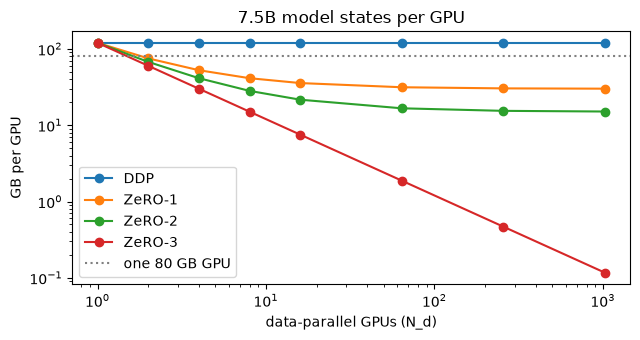

In [14]:
def zero_gb_per_gpu(psi, n_gpus, stage, k=12):
    """Model-state memory per GPU (GB) for DDP (stage 0) and ZeRO stages 1–3."""
    if stage == 0:
        per_gpu = (2 + 2 + k) * psi
    elif stage == 1:
        per_gpu = 2 * psi + 2 * psi + k * psi / n_gpus
    elif stage == 2:
        per_gpu = 2 * psi + (2 + k) * psi / n_gpus
    elif stage == 3:
        per_gpu = (2 + 2 + k) * psi / n_gpus
    else:
        raise ValueError("stage must be 0, 1, 2, or 3")
    return per_gpu / GB


PAPER_FIGURE_1 = {0: 120.0, 1: 31.4, 2: 16.6, 3: 1.9}
ours_figure_1 = {stage: round(zero_gb_per_gpu(7.5e9, 64, stage), 1) for stage in PAPER_FIGURE_1}
print("ZeRO paper Figure 1:", PAPER_FIGURE_1)
print("our formulas        :", ours_figure_1)
assert ours_figure_1 == PAPER_FIGURE_1

stage_names = {0: "DDP", 1: "ZeRO-1", 2: "ZeRO-2", 3: "ZeRO-3"}
gpu_counts = [1, 2, 4, 8, 16, 64, 256, 1024]
zero_table = pd.DataFrame({stage_names[s]: [zero_gb_per_gpu(7.5e9, n, s) for n in gpu_counts] for s in stage_names}, index=gpu_counts)
zero_table.index.name = "GPUs"
print("\n7.5B model, GB of model states PER GPU:")
print(zero_table.round(2).to_string())
print("\nreduction vs DDP on 8 GPUs :", {name: f"{120 / zero_table.loc[8, name]:.1f}×" for name in zero_table.columns})
print("reduction vs DDP on 64 GPUs:", {name: f"{120 / zero_table.loc[64, name]:.1f}×" for name in zero_table.columns})

fig, ax = plt.subplots(figsize=(6.5, 3.5))
for name in zero_table.columns:
    ax.plot(zero_table.index, zero_table[name], marker="o", label=name)
ax.axhline(80, color="gray", ls=":", label="one 80 GB GPU")
ax.set(xscale="log", yscale="log", xlabel="data-parallel GPUs (N_d)", ylabel="GB per GPU", title="7.5B model states per GPU")
ax.legend()
plt.tight_layout()
plt.show()

Read the table carefully:

- **ZeRO-1 and ZeRO-2 flatten out** — at most 4× and 8× savings however many GPUs you add, because every GPU still holds the full 16-bit parameters (and, for ZeRO-1, gradients).
- **Only ZeRO-3 scales linearly**: N_d GPUs → N_d× less. The paper's "64× reduction" is for **N_d = 64**; on 8 GPUs ZeRO-3 saves **8×**, not 64×.
- Activations are **not** in these numbers. ZeRO-R partitions activation checkpoints when combined with tensor parallelism; **ZeRO-Offload** moves optimizer states and gradients to CPU memory (its paper trains 13B-parameter models on a single GPU); **ZeRO-Infinity** adds NVMe offload.

### ✍️ Your Turn

Store the per-GPU model-state memory in GB for a **13B** model with **ZeRO-2** on **8** GPUs in `zero2_13b_gb`.

In [15]:
zero2_13b_gb = None  # TODO: your code here
check("zero2_13b_gb", zero2_13b_gb, 48.75, hint="2Ψ + (2 + 12)Ψ / 8, with Ψ = 13e9, divided by 1e9")

⏳ zero2_13b_gb: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
zero2_13b_gb = zero_gb_per_gpu(13e9, 8, stage=2)
check("zero2_13b_gb", zero2_13b_gb, 48.75)
```

26 GB of bf16 parameters on every GPU + 22.75 GB for this GPU's shard of gradients and optimizer states. With activations it fits an 80 GB GPU; on 40 GB GPUs you'd need ZeRO-3.
</details>

> 💡 **Interview angle:** "Explain the ZeRO stages." — shard optimizer states (1), then gradients (2), then parameters (3) across data-parallel GPUs. Per GPU: 4Ψ + 12Ψ/N, 2Ψ + 14Ψ/N, 16Ψ/N bytes. Stages 1–2 keep DDP's communication volume; stage 3 adds parameter all-gathers (~1.5×) but is the only one whose memory keeps falling as N grows.

## 7. FSDP2 (fully_shard) and How It Maps to ZeRO-3 🟡

**FSDP** (Fully Sharded Data Parallel) is PyTorch's native implementation of the ZeRO-3 idea. The current API, **FSDP2**, is `torch.distributed.fsdp.fully_shard`:

1. You call `fully_shard(block)` on each transformer block (a **unit**), then on the whole model.
2. Each parameter becomes a **DTensor** sharded along dimension 0: each rank stores only its slice.
3. **Forward:** before a unit runs, FSDP **all-gathers** its full parameters; after it runs, it frees them again (`reshard_after_forward=True`).
4. **Backward:** all-gather again, compute gradients, then **reduce-scatter** so each rank keeps only its averaged gradient shard. The optimizer updates local shards, so optimizer states are sharded too.

| FSDP setting | Equivalent idea |
|---|---|
| `fully_shard(module)` (default `reshard_after_forward=True`) | ZeRO-3 |
| `reshard_after_forward=False` | ZeRO-2-like: keep gathered parameters between forward and backward — faster, more memory |
| FSDP1 `ShardingStrategy.SHARD_GRAD_OP` / `NO_SHARD` / `HYBRID_SHARD` | ZeRO-2 / DDP / shard within a node, replicate across nodes |
| `MixedPrecisionPolicy(param_dtype=torch.bfloat16, reduce_dtype=torch.float32)` | bf16 compute with sharded fp32 parameters |
| `CPUOffloadPolicy()` | parameter and optimizer offload (ZeRO-Offload style) |

A real run on 2 CPU processes with gloo. One detail for this laptop: `fully_shard` builds its device mesh on the *accelerator* by default (MPS here), which gloo cannot use, so the script passes an explicit **CPU mesh**. The script checks that the sharded model ends up equal to single-process training on the same global batches, and prints what each rank actually stores.

In [16]:
FSDP_SCRIPT = OUTPUT_DIR / "fsdp2_train.py"
FSDP_SCRIPT.write_text(textwrap.dedent('''
    import json, sys
    import torch, torch.distributed as dist, torch.nn as nn, torch.nn.functional as F
    from torch.distributed.device_mesh import init_device_mesh
    from torch.distributed.fsdp import fully_shard
    from torch.utils.data import DistributedSampler, TensorDataset

    BATCH, LR, STEPS = 32, 1e-3, 20

    class Block(nn.Module):
        def __init__(self, d=64, hidden=256):
            super().__init__()
            self.norm, self.up, self.down = nn.LayerNorm(d), nn.Linear(d, hidden), nn.Linear(hidden, d)
        def forward(self, x):
            return x + self.down(F.gelu(self.up(self.norm(x))))

    def make_model():
        torch.manual_seed(0)
        return nn.Sequential(*[Block() for _ in range(4)], nn.Linear(64, 10))

    def main():
        dist.init_process_group("gloo")
        rank, world = dist.get_rank(), dist.get_world_size()
        data = torch.load(sys.argv[1])
        X, y = data["X"].float(), data["y"]
        dataset = TensorDataset(X, y)
        mesh = init_device_mesh("cpu", (world,))               # explicit CPU mesh for the gloo backend

        model = make_model()
        full_param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
        for block in model[:4]:
            fully_shard(block, mesh=mesh)                      # each block is a unit: gathered only while it runs
        fully_shard(model, mesh=mesh)                          # the root unit holds the remaining head layer
        opt = torch.optim.AdamW(model.parameters(), lr=LR)
        sampler = DistributedSampler(dataset, num_replicas=world, rank=rank, shuffle=True, seed=0, drop_last=True)
        order = list(sampler)
        for step in range(STEPS):
            idx = order[step * BATCH:(step + 1) * BATCH]
            loss = F.cross_entropy(model(X[idx]), y[idx])
            opt.zero_grad()
            loss.backward()                                    # reduce-scatter: each rank keeps its averaged gradient shard
            opt.step()                                         # AdamW updates only the local shard

        w = model[0].up.weight
        local_param_bytes = sum(p.to_local().numel() * p.to_local().element_size() for p in model.parameters())
        exp_avg = opt.state[w]["exp_avg"]
        print(f"rank {rank}: up.weight is a {type(w).__name__} global {tuple(w.shape)} → local shard {tuple(w.to_local().shape)} | "
              f"Adam exp_avg local {tuple(exp_avg.to_local().shape)} | parameter bytes stored {local_param_bytes:,} of {full_param_bytes:,}", flush=True)

        full_state = {k: v.full_tensor() for k, v in model.state_dict().items()}   # all-gather for checkpointing/eval
        if rank == 0:
            ref = make_model()
            ref_opt = torch.optim.AdamW(ref.parameters(), lr=LR)
            per_rank = [list(DistributedSampler(dataset, num_replicas=world, rank=r, shuffle=True, seed=0, drop_last=True)) for r in range(world)]
            for step in range(STEPS):
                loss = sum(F.cross_entropy(ref(X[p[step * BATCH:(step + 1) * BATCH]]), y[p[step * BATCH:(step + 1) * BATCH]]) for p in per_rank) / world
                ref_opt.zero_grad()
                loss.backward()
                ref_opt.step()
            gap = max((full_state[k] - v).abs().max().item() for k, v in ref.state_dict().items())
            json.dump({"max_gap_vs_single_process": gap, "local_param_bytes": local_param_bytes, "full_param_bytes": full_param_bytes},
                      open(sys.argv[2], "w"))
        dist.destroy_process_group()

    if __name__ == "__main__":
        main()
'''))

FSDP_RESULT = OUTPUT_DIR / "fsdp2_result.json"
print(torchrun(FSDP_SCRIPT, DATA_PATH, FSDP_RESULT))
fsdp_result = json.loads(FSDP_RESULT.read_text())
print(f"\nmax gap vs single-process AdamW training: {fsdp_result['max_gap_vs_single_process']:.1e} (float32)")
print(f"rank 0 stores {fsdp_result['local_param_bytes'] / fsdp_result['full_param_bytes']:.0%} of the parameter bytes")
assert fsdp_result["max_gap_vs_single_process"] < 1e-4

rank 0: up.weight is a DTensor global (256, 64) → local shard (128, 64) | Adam exp_avg local (128, 64) | parameter bytes stored 267,028 of 534,056
rank 1: up.weight is a DTensor global (256, 64) → local shard (128, 64) | Adam exp_avg local (128, 64) | parameter bytes stored 267,028 of 534,056

max gap vs single-process AdamW training: 0.0e+00 (float32)
rank 0 stores 50% of the parameter bytes


Each rank stored **half** of every sharded tensor (rows 0–127 on rank 0, 128–255 on rank 1 for the 256 × 64 weight) and half of its Adam state, yet the gathered model equals ordinary training up to float32 rounding. On real GPUs the same code uses `init_device_mesh("cuda", …)` implicitly with NCCL, wraps every transformer block, and adds a `MixedPrecisionPolicy`.

> 💡 **Interview angle:** "FSDP vs DeepSpeed ZeRO-3?" — same core idea (shard params, grads, and optimizer states; all-gather per unit; reduce-scatter grads). FSDP is native PyTorch (FSDP2 = per-parameter DTensor sharding, composes with tensor parallelism and `torch.compile`); DeepSpeed adds a config-driven engine with extras like NVMe offload (ZeRO-Infinity). Wrapping granularity (per transformer block) controls peak memory.

## 8. Tensor, Pipeline, and Sequence/Context Parallelism 🟡

Data parallelism (even ZeRO-3) runs each layer's full computation on one GPU. When a **single layer's activations** or **per-step latency** are the problem, you also split the model itself:

| Type | What is split | Communication | Where it runs best |
|---|---|---|---|
| **Tensor parallelism (TP)** (Megatron-LM) | individual weight matrices: MLP column-parallel then row-parallel; attention heads | an all-reduce in every layer's forward **and** backward | inside one node (NVLink) — very chatty |
| **Pipeline parallelism (PP)** (GPipe, 1F1B) | layers into sequential stages | point-to-point activations between neighbours | across nodes — little traffic, but idle "bubbles" |
| **Sequence parallelism (SP)** | LayerNorm/dropout activations along the sequence dimension, inside TP regions | replaces TP's all-reduce with all-gather + reduce-scatter | together with TP |
| **Context parallelism (CP)** (Ring Attention, DeepSpeed-Ulysses) | the sequence itself across GPUs, including attention | pass key/value blocks around a ring, or all-to-all over heads | 100K+ token contexts |
| **Expert parallelism (EP)** | mixture-of-experts experts on different GPUs | all-to-all token routing | MoE models |

Large runs combine them — **3D parallelism**: world size = TP × PP × DP (e.g. TP = 8 inside each node, PP across nodes, DP/ZeRO over the replicas).

**Tensor parallelism in one process.** A column-parallel linear layer splits the weight's **rows** (output features) across GPUs; each GPU computes its slice and an all-gather concatenates them. We simulate 2 GPUs with two weight shards:

In [17]:
torch.manual_seed(SEED)
full_linear = nn.Linear(64, 256, bias=False)
x_tp = torch.randn(8, 64)
w_shards = full_linear.weight.detach().chunk(2, dim=0)              # GPU0: rows 0–127, GPU1: rows 128–255
partial_outputs = [x_tp @ w.T for w in w_shards]                    # each GPU computes only its slice
tp_output = torch.cat(partial_outputs, dim=-1)                      # all-gather along the feature dimension
print("shard shapes:", [tuple(w.shape) for w in w_shards], "→ output", tuple(tp_output.shape))
print(f"max |difference| vs the unsharded layer: {(tp_output - full_linear(x_tp)).abs().max().item():.1e}")
assert torch.allclose(tp_output, full_linear(x_tp), atol=1e-6)

shard shapes: [(128, 64), (128, 64)] → output (8, 256)
max |difference| vs the unsharded layer: 0.0e+00


**The pipeline bubble.** With p stages and m micro-batches, GPipe-style schedules leave a fraction **(p − 1) / (m + p − 1)** of the time idle. More micro-batches shrink the bubble (1F1B schedules keep the same bubble but hold fewer micro-batches' activations at once; interleaved schedules shrink it further).

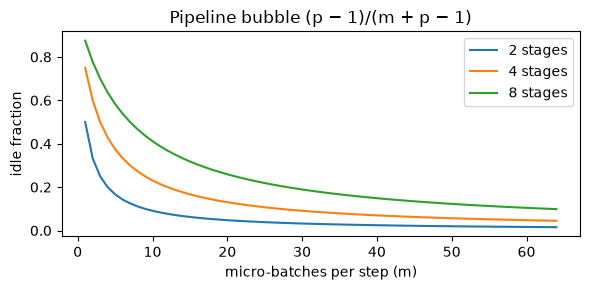

{'p=8, m=1': 0.875, 'p=8, m=8': 0.467, 'p=8, m=32': 0.179, 'p=8, m=64': 0.099}


In [18]:
def bubble_fraction(stages, micro_batches):
    return (stages - 1) / (micro_batches + stages - 1)


micro = np.arange(1, 65)
fig, ax = plt.subplots(figsize=(6, 3))
for p in [2, 4, 8]:
    ax.plot(micro, [bubble_fraction(p, m) for m in micro], label=f"{p} stages")
ax.set(xlabel="micro-batches per step (m)", ylabel="idle fraction", title="Pipeline bubble (p − 1)/(m + p − 1)")
ax.legend()
plt.tight_layout()
plt.show()
print({f"p=8, m={m}": round(bubble_fraction(8, m), 3) for m in [1, 8, 32, 64]})

### ✍️ Your Turn

A pipeline has **4** stages and uses **12** micro-batches per step. Store the bubble fraction in `my_bubble`.

In [19]:
my_bubble = None  # TODO: your code here
check("my_bubble", my_bubble, 0.2, hint="(p − 1) / (m + p − 1)")

⏳ my_bubble: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
my_bubble = bubble_fraction(4, 12)      # 3 / 15
check("my_bubble", my_bubble, 0.2)
```
</details>

> 💡 **Interview angle:** "TP vs PP vs DP — where does each go?" — TP inside a node because it all-reduces every layer (needs NVLink-class links); PP across nodes because it only sends activations between neighbouring stages, but you pay a bubble; DP/ZeRO on the outside for throughput. Add CP for very long sequences and EP for MoE.

## 9. Communication Costs: Ring All-Reduce 🟡

The collectives you will hear about:

| Collective | Result on every rank | Used by |
|---|---|---|
| **all-reduce** | the sum/mean of everyone's tensor | DDP gradients, TP layers |
| **reduce-scatter** | *your shard* of the sum | ZeRO-2/3 and FSDP gradients |
| **all-gather** | everyone's shards concatenated | ZeRO-3/FSDP parameters, TP outputs |
| **broadcast** | rank 0's tensor | initial weights |
| **all-to-all** | a personalised piece from every rank | MoE routing, Ulysses attention |

**Ring all-reduce** arranges N GPUs in a ring and runs **reduce-scatter** (N − 1 steps) then **all-gather** (N − 1 steps), each step sending one 1/N-sized chunk to the next neighbour. Every GPU sends

$$\frac{2(N-1)}{N} \times \text{message size}$$

— almost exactly **2 × the gradient size, regardless of N**. That is why ring all-reduce scales: per-GPU traffic doesn't grow with more GPUs (the number of steps, and so latency, does). You will build it in Build It From Scratch.

Time ≈ bytes sent ÷ link bandwidth (ignoring per-message latency). The link speeds below are **example parameters** in the units network cards are sold in; the last row is the gloo speed **measured** between the two local processes in Section 5.

In [20]:
def ring_allreduce_bytes_per_gpu(message_bytes, n_gpus):
    return 2 * (n_gpus - 1) / n_gpus * message_bytes


grad_bytes_7b = 7e9 * 2                                       # bf16 gradients of a 7B model
links = {"100 Gbit/s Ethernet (example)": 100 / 8 * GB, "400 Gbit/s InfiniBand (example)": 400 / 8 * GB,
         "local gloo, measured in Section 5": ddp_result["allreduce_64MB_MB_per_s"] * 1e6}
comm_rows = []
for n in [2, 8, 64]:
    sent = ring_allreduce_bytes_per_gpu(grad_bytes_7b, n)
    comm_rows.append({"GPUs": n, "GB sent per GPU": sent / GB, **{f"seconds: {k}": sent / bps for k, bps in links.items()}})
print("all-reduce of 7B bf16 gradients (14 GB):")
pd.DataFrame(comm_rows).round(1)

all-reduce of 7B bf16 gradients (14 GB):


,GPUs,GB sent per GPU,seconds: 100 Gbit/s Ethernet (example),seconds: 400 Gbit/s InfiniBand (example),"seconds: local gloo, measured in Section 5"
0,2,14.0,1.1,0.3,3.8
1,8,24.5,2.0,0.5,6.7
2,64,27.6,2.2,0.6,7.5


At 100 Gbit/s, synchronizing a 7B model's gradients costs seconds **every step** (see the table) — time the GPUs spend waiting instead of computing. Real systems overlap communication with the backward pass, bucket gradients, use NVLink inside nodes and InfiniBand/RoCE between them, and pick sharding and parallelism layouts that keep the heaviest traffic on the fastest links.

### ✍️ Your Turn

Store the GB each GPU sends in a ring all-reduce of a **1 GB** gradient across **8** GPUs in `sent_gb`.

In [21]:
sent_gb = None  # TODO: your code here
check("sent_gb", sent_gb, 1.75, hint="2(N − 1)/N × size")

⏳ sent_gb: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
sent_gb = ring_allreduce_bytes_per_gpu(1 * GB, 8) / GB
check("sent_gb", sent_gb, 1.75)
```
</details>

> 💡 **Interview angle:** "What does all-reduce cost?" — ring all-reduce = reduce-scatter + all-gather; each GPU sends 2(N−1)/N × message size (≈ 2×, independent of N) over 2(N−1) steps. ZeRO-1/2 keep that 2Ψ volume; ZeRO-3/FSDP add a parameter all-gather (≈ 3Ψ total). Tree algorithms (NCCL) cut latency at large N.

## 10. DeepSpeed Configuration, Explained Correctly 🟡

**DeepSpeed** is Microsoft's training library that implements ZeRO, offloading, and more through a JSON config. The rule people get wrong:

$$\texttt{train\_batch\_size} = \texttt{train\_micro\_batch\_size\_per\_gpu} \times \texttt{gradient\_accumulation\_steps} \times \text{world size}$$

DeepSpeed checks this when it starts and refuses inconsistent values (you may give any two of the three and it derives the third). A correct ZeRO-3 config for **8 GPUs**:

In [22]:
ds_config = {
    "train_batch_size": 256,                          # = 4 × 8 × 8
    "train_micro_batch_size_per_gpu": 4,
    "gradient_accumulation_steps": 8,
    "gradient_clipping": 1.0,
    "bf16": {"enabled": True},
    "zero_optimization": {
        "stage": 3,
        "overlap_comm": True,                          # communicate while backward is still running
        "contiguous_gradients": True,                  # fewer memory fragments
        "offload_optimizer": {"device": "cpu", "pin_memory": True},   # optional: optimizer states to CPU RAM
        "stage3_gather_16bit_weights_on_model_save": True,            # save a normal full checkpoint
    },
}


def check_ds_batch(config, world_size):
    micro, accum = config["train_micro_batch_size_per_gpu"], config["gradient_accumulation_steps"]
    expected = micro * accum * world_size
    if config["train_batch_size"] != expected:
        raise ValueError(f"train_batch_size={config['train_batch_size']} but micro {micro} × accumulation {accum} × world {world_size} = {expected}")
    return expected


print("global batch:", check_ds_batch(ds_config, world_size=8), "sequences per optimizer step")
CONFIG_PATH = OUTPUT_DIR / "ds_config_zero3.json"
CONFIG_PATH.write_text(json.dumps(ds_config, indent=2))
print("wrote", CONFIG_PATH)

global batch: 256 sequences per optimizer step
wrote _outputs/distributed/ds_config_zero3.json


| Key | Meaning |
|---|---|
| `zero_optimization.stage` | 0 = DDP-like, 1/2/3 = ZeRO stages from Section 6 |
| `offload_optimizer` / `offload_param` | move optimizer states / parameters to `"cpu"` or `"nvme"` (slower steps, much less GPU memory) |
| `overlap_comm`, `contiguous_gradients` | performance and fragmentation settings |
| `bf16.enabled` / `fp16.enabled` | mixed precision (fp16 adds dynamic loss scaling) |
| `stage3_gather_16bit_weights_on_model_save` | gather shards into a normal checkpoint at save time |
| `"auto"` values | allowed when used through Hugging Face `Trainer`/`accelerate`, which fill them from `TrainingArguments` |

**How it's launched.** DeepSpeed training is a **script started by a launcher** that creates one process per GPU and sets `RANK`, `LOCAL_RANK`, `WORLD_SIZE`, and the master address: `deepspeed --num_gpus 8 train.py --deepspeed ds_config.json`, `torchrun --nproc_per_node 8 train.py`, or `accelerate launch --config_file … train.py` (with Hugging Face `TrainingArguments(deepspeed="ds_config.json")`). Calling `deepspeed.initialize()` inside a notebook cell has no launcher, so there are no other ranks — at best a world size of 1 with none of the multi-GPU sharding the config describes.

In [23]:
import importlib.util

if importlib.util.find_spec("deepspeed") is not None and torch.cuda.device_count() >= 2:
    print("DeepSpeed and multiple CUDA GPUs found — launch a training script with:")
    print(f"  deepspeed --num_gpus {torch.cuda.device_count()} train.py --deepspeed {CONFIG_PATH}")
else:
    print("⏭️ Skipped: running DeepSpeed needs `pip install deepspeed` and CUDA GPUs, started from a launcher script "
          "(not a notebook cell). The config above is validated with plain Python instead.")

⏭️ Skipped: running DeepSpeed needs `pip install deepspeed` and CUDA GPUs, started from a launcher script (not a notebook cell). The config above is validated with plain Python instead.


### ✍️ Your Turn

You want a global batch of **256** sequences on **16** GPUs with micro-batches of **4**. Store the required `gradient_accumulation_steps` in `accum_steps`.

In [24]:
accum_steps = None  # TODO: your code here
check("accum_steps", accum_steps, 4, hint="256 / (4 × 16)")

⏳ accum_steps: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
accum_steps = 256 // (4 * 16)
check("accum_steps", accum_steps, 4)
check_ds_batch({"train_batch_size": 256, "train_micro_batch_size_per_gpu": 4, "gradient_accumulation_steps": accum_steps}, world_size=16)
```
If the division isn't exact, change the micro-batch size or the global batch — never round silently.
</details>

> 💡 **Interview angle:** "Your DeepSpeed job fails at startup with a batch-size assertion." — `train_batch_size` must equal micro × accumulation × world size; world size changes when you move from 8 to 16 GPUs, so either use `"auto"` via HF integration, specify only two of the three, or recompute.

## 11. A Planning Checklist 🟢

Before you request GPUs for a training job, answer these in order:

1. **Do I need full fine-tuning?** LoRA/QLoRA often gets most of the quality at a fraction of the memory ([Fine-Tuning with LoRA and DPO](07_Fine_Tuning_LoRA_and_DPO.ipynb)).
2. **Model states per GPU:** 16 bytes/param for mixed-precision Adam (8-bit Adam ≈ 10), divided by N only for what you shard (Section 6).
3. **Activations per GPU:** micro-batch × sequence length × hidden × layers; turn on gradient checkpointing and FlashAttention before buying more GPUs (Section 3).
4. **Headroom:** leave 10–20% for CUDA context, communication buffers, and fragmentation.
5. **Pick the least-communicating strategy that fits:** DDP → ZeRO-1 → ZeRO-2 → ZeRO-3/FSDP → + CPU offload → + tensor/pipeline parallelism. Decide **per GPU**, never by adding up all GPUs' memory.
6. **Global batch:** micro × accumulation × data-parallel size; keep it (and the learning rate) constant when the number of GPUs changes.
7. **Network:** TP only within NVLink domains; check the all-reduce time per step against compute time (Section 9).
8. **Throughput and cost:** 6·N·D FLOPs ÷ (GPUs × FLOPs/s × MFU) → days → dollars; measure MFU on a short run.
9. **Reliability:** sharded checkpoints every N minutes, resumable data loaders, `set_epoch` on samplers, timeouts for hung collectives.
10. **Verify at small scale:** 1 GPU vs 2 GPUs must give the same loss curve for the same global batch before scaling to 64.

> 💡 **Interview angle:** "Plan fine-tuning of a 70B model." — full FT: 1,120 GB model states → ZeRO-3/FSDP over ≥ 16–32 × 80 GB GPUs with checkpointing (plus offload if fewer); LoRA: ~140 GB bf16 base, shard it with FSDP across a few GPUs; QLoRA: ~35 GB base fits one 80 GB GPU. State assumptions (sequence length, micro-batch) and verify with a short run.

## 🔧 Build It From Scratch

### 1) Ring all-reduce across worker threads

N workers in a ring, each with its own gradient vector split into N chunks. **Reduce-scatter:** for N − 1 steps, each worker sends one chunk to its right neighbour, which adds it to its own copy; afterwards every chunk's full sum lives on exactly one worker. **All-gather:** for N − 1 more steps, workers pass the finished chunks around, overwriting. Each worker is a thread with a mailbox (`queue.Queue`), so messages really travel between concurrent workers. We check the result against NumPy's sum **and** against the real gloo all-reduce measured in Section 5, and count the bytes each worker sent.

In [25]:
def ring_all_reduce(worker_vectors):
    """Sum vectors across workers with the ring algorithm. Returns (per-worker results, bytes sent per worker)."""
    n = len(worker_vectors)
    chunks = [np.array_split(np.asarray(v, dtype=np.float64).copy(), n) for v in worker_vectors]
    mailboxes = [queue.Queue() for _ in range(n)]
    bytes_sent = [0] * n

    def worker(rank):
        right = (rank + 1) % n
        for step in range(n - 1):                                  # phase 1: reduce-scatter
            send_idx = (rank - step) % n
            payload = chunks[rank][send_idx].copy()
            mailboxes[right].put((send_idx, payload))
            bytes_sent[rank] += payload.nbytes
            recv_idx, data = mailboxes[rank].get()                 # from the left neighbour
            chunks[rank][recv_idx] += data
        for step in range(n - 1):                                  # phase 2: all-gather
            send_idx = (rank + 1 - step) % n
            payload = chunks[rank][send_idx].copy()
            mailboxes[right].put((send_idx, payload))
            bytes_sent[rank] += payload.nbytes
            recv_idx, data = mailboxes[rank].get()
            chunks[rank][recv_idx] = data

    threads = [threading.Thread(target=worker, args=(r,)) for r in range(n)]
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    return [np.concatenate(c) for c in chunks], bytes_sent


rng = np.random.default_rng(SEED)
for n_workers in [2, 3, 5, 8]:
    grads = [rng.normal(size=840) for _ in range(n_workers)]        # 840 splits evenly for every N here
    results, sent = ring_all_reduce(grads)
    expected_sum = np.sum(grads, axis=0)
    assert all(np.allclose(r, expected_sum) for r in results)
    assert all(np.allclose(r / n_workers, np.mean(grads, axis=0)) for r in results)   # divide by N → DDP's average
    assert all(s == 2 * (n_workers - 1) / n_workers * grads[0].nbytes for s in sent)
    print(f"N={n_workers}: every worker holds the exact sum ✅ | each sent {sent[0]:,} bytes = 2(N−1)/N × {grads[0].nbytes:,}")

gloo_inputs = [np.arange(8) * (rank + 1) for rank in range(ddp_result["world_size"])]
ours_vs_gloo, _ = ring_all_reduce(gloo_inputs)
print("our ring:", ours_vs_gloo[0].tolist(), "| gloo all_reduce from Section 5:", ddp_result["allreduce_sum"])
assert np.allclose(ours_vs_gloo[0], ddp_result["allreduce_sum"])

N=2: every worker holds the exact sum ✅ | each sent 6,720 bytes = 2(N−1)/N × 6,720
N=3: every worker holds the exact sum ✅ | each sent 8,960 bytes = 2(N−1)/N × 6,720
N=5: every worker holds the exact sum ✅ | each sent 10,752 bytes = 2(N−1)/N × 6,720
N=8: every worker holds the exact sum ✅ | each sent 11,760 bytes = 2(N−1)/N × 6,720
our ring: [0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0] | gloo all_reduce from Section 5: [0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0]


### 2) A per-GPU memory planner

The planner tries strategies from least to most communication and returns the first whose **per-GPU** need (model states for that stage + activations) fits in the GPU's usable memory. Next to it, the buggy "wizard" logic: it adds up all GPUs' memory and picks ZeRO-1 whenever the model's total states fit in that sum.

In [26]:
STRATEGIES = [("DDP", 0), ("ZeRO-1", 1), ("ZeRO-2", 2), ("ZeRO-3 / FSDP", 3)]
NO_FIT = "does not fit — add CPU/NVMe offload, tensor/pipeline parallelism, more GPUs, or use LoRA/QLoRA"


def plan_training(n_params, n_gpus, gpu_gb, activation_gb_per_gpu, headroom=0.10):
    usable = gpu_gb * (1 - headroom)
    rows = [{"strategy": name, "GB per GPU": zero_gb_per_gpu(n_params, n_gpus, stage) + activation_gb_per_gpu} for name, stage in STRATEGIES]
    for row in rows:
        row["fits"] = row["GB per GPU"] <= usable
    choice = next((row["strategy"] for row in rows if row["fits"]), NO_FIT)
    return choice, pd.DataFrame(rows).round(2)


def buggy_wizard(n_params, n_gpus, gpu_gb):
    total_states_gb = n_params * 16 / GB
    return "ZeRO-1" if total_states_gb <= n_gpus * gpu_gb else "ZeRO-3"        # ❌ compares against ALL GPUs combined


cases = [
    ("7B on 8 × 40 GB, 4 GB activations/GPU", 7e9, 8, 40, 4, "ZeRO-2"),
    ("7.5B on 64 × 32 GB, 2 GB activations/GPU", 7.5e9, 64, 32, 2, "ZeRO-2"),
    ("1.3B on 4 × 80 GB, 20 GB activations/GPU", 1.3e9, 4, 80, 20, "DDP"),
    ("70B on 8 × 80 GB, 8 GB activations/GPU", 70e9, 8, 80, 8, NO_FIT),
    ("70B on 32 × 80 GB, 8 GB activations/GPU", 70e9, 32, 80, 8, "ZeRO-3 / FSDP"),
]
for label, n, gpus, mem, act, expected in cases:
    choice, detail = plan_training(n, gpus, mem, act)
    wizard = buggy_wizard(n, gpus, mem)
    wizard_need = float(detail.loc[detail.strategy.str.startswith(wizard), "GB per GPU"].iloc[0])
    print(f"{label:44s} → planner: {choice[:24]:24s} | buggy wizard: {wizard} needs {wizard_need:.0f} GB/GPU → "
          f"{'fits' if wizard_need <= 0.9 * mem else 'DOES NOT FIT'}")
    assert choice == expected
print("\ndetail for the first case (usable = 36 GB per GPU):")
print(plan_training(7e9, 8, 40, 4)[1].to_string(index=False))

7B on 8 × 40 GB, 4 GB activations/GPU        → planner: ZeRO-2                   | buggy wizard: ZeRO-1 needs 42 GB/GPU → DOES NOT FIT
7.5B on 64 × 32 GB, 2 GB activations/GPU     → planner: ZeRO-2                   | buggy wizard: ZeRO-1 needs 33 GB/GPU → DOES NOT FIT
1.3B on 4 × 80 GB, 20 GB activations/GPU     → planner: DDP                      | buggy wizard: ZeRO-1 needs 29 GB/GPU → fits
70B on 8 × 80 GB, 8 GB activations/GPU       → planner: does not fit — add CPU/N | buggy wizard: ZeRO-3 needs 148 GB/GPU → DOES NOT FIT
70B on 32 × 80 GB, 8 GB activations/GPU      → planner: ZeRO-3 / FSDP            | buggy wizard: ZeRO-1 needs 314 GB/GPU → DOES NOT FIT

detail for the first case (usable = 36 GB per GPU):
     strategy  GB per GPU  fits
          DDP      116.00 False
       ZeRO-1       42.50 False
       ZeRO-2       30.25  True
ZeRO-3 / FSDP       18.00  True


For 7B on 8 × 40 GB, the wizard says ZeRO-1 because 112 GB < 320 GB in total — but ZeRO-1 still needs 42.5 GB **on each GPU**, which doesn't fit in the 36 GB usable. The end of each output line shows whether the wizard's pick really fits per GPU; it also picks sharding when plain DDP would do. Always reason per GPU.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Counting 12 bytes per parameter for mixed precision

In [27]:
print(f"❌ 2 + 2 + 4 + 4 (no fp32 master copy): 7B needs {model_state_gb(7e9, 'mixed precision, master weights forgotten (WRONG)'):.0f} GB "
      f"→ 'fits' on one 94 GB GPU")
print(f"✅ 2 + 2 + 4 (master) + 4 + 4          : 7B needs {model_state_gb(7e9):.0f} GB → it does not")

❌ 2 + 2 + 4 + 4 (no fp32 master copy): 7B needs 84 GB → 'fits' on one 94 GB GPU
✅ 2 + 2 + 4 (master) + 4 + 4          : 7B needs 112 GB → it does not


### ❌ Pitfall 2 — "ZeRO-3 gives 64× savings on 8 GPUs"

In [28]:
claimed = 64
actual_8 = zero_gb_per_gpu(7.5e9, 8, 0) / zero_gb_per_gpu(7.5e9, 8, 3)
actual_64 = zero_gb_per_gpu(7.5e9, 64, 0) / zero_gb_per_gpu(7.5e9, 64, 3)
print(f"❌ claimed on 8 GPUs: {claimed}× → {zero_gb_per_gpu(7.5e9, 1, 0) / claimed:.2f} GB per GPU for 7.5B")
print(f"✅ computed: {actual_8:.0f}× on 8 GPUs ({zero_gb_per_gpu(7.5e9, 8, 3):.2f} GB per GPU); the paper's {actual_64:.0f}× needs 64 GPUs")

❌ claimed on 8 GPUs: 64× → 1.88 GB per GPU for 7.5B
✅ computed: 8× on 8 GPUs (15.00 GB per GPU); the paper's 64× needs 64 GPUs


### ❌ Pitfall 3 — A DeepSpeed batch config that breaks micro × accumulation × world

In [29]:
bad_config = {"train_batch_size": 32, "train_micro_batch_size_per_gpu": 4, "gradient_accumulation_steps": 4}
try:
    check_ds_batch(bad_config, world_size=8)
except ValueError as err:
    print("❌", err)
good_config = {**bad_config, "train_batch_size": 4 * 4 * 8}
print("✅ train_batch_size =", check_ds_batch(good_config, world_size=8))

❌ train_batch_size=32 but micro 4 × accumulation 4 × world 8 = 128
✅ train_batch_size = 128


### ❌ Pitfall 4 — A "GPT-style" model built from `nn.TransformerEncoder` without a causal mask

A language model must not see future tokens. Without a mask, changing tokens **after** position t changes the output **at** t — the model is cheating during training and will fail at generation.

In [30]:
torch.manual_seed(SEED)
encoder = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model=32, nhead=4, dropout=0.0, batch_first=True),
                                num_layers=2, enable_nested_tensor=False).eval()
tokens = torch.randn(1, 10, 32)
future_changed = tokens.clone()
future_changed[:, 5:] = torch.randn(1, 5, 32)                     # change only positions 5–9
causal_mask = nn.Transformer.generate_square_subsequent_mask(10)

with torch.no_grad():
    leak = (encoder(tokens)[:, :5] - encoder(future_changed)[:, :5]).abs().max().item()
    no_leak = (encoder(tokens, mask=causal_mask, is_causal=True)[:, :5]
               - encoder(future_changed, mask=causal_mask, is_causal=True)[:, :5]).abs().max().item()
print(f"❌ no mask    : outputs at positions 0–4 changed by up to {leak:.3f} when only the future changed")
print(f"✅ causal mask: change {no_leak:.1e} — positions 0–4 cannot see positions 5–9")

❌ no mask    : outputs at positions 0–4 changed by up to 0.853 when only the future changed
✅ causal mask: change 0.0e+00 — positions 0–4 cannot see positions 5–9


### ❌ Pitfall 5 — Accumulating gradients without scaling the loss

In [31]:
unscaled = make_mlp()
for micro_x, micro_y in zip(xb.chunk(4), yb.chunk(4)):
    F.cross_entropy(unscaled(micro_x), micro_y).backward()            # ❌ no division by the number of micro-batches
ratio = unscaled[0].weight.grad.norm() / big[0].weight.grad.norm()
print(f"❌ unscaled accumulation: gradient is {ratio:.2f}× the big-batch gradient (like a 4× learning rate)")
print(f"✅ loss / 4 (Section 4): max difference {max_diff:.1e}")

❌ unscaled accumulation: gradient is 4.00× the big-batch gradient (like a 4× learning rate)
✅ loss / 4 (Section 4): max difference 1.7e-17


### ❌ Pitfall 6 — Forgetting `sampler.set_epoch(epoch)`

In [32]:
from torch.utils.data import DistributedSampler

sampler = DistributedSampler(range(12), num_replicas=2, rank=0, shuffle=True, seed=0)
without = [list(sampler) for _ in range(2)]
with_epochs = []
for epoch in range(2):
    sampler.set_epoch(epoch)
    with_epochs.append(list(sampler))
print("❌ without set_epoch, epochs 0 and 1:", without, "→ identical order every epoch")
print("✅ with set_epoch(epoch)            :", with_epochs)

❌ without set_epoch, epochs 0 and 1: [[8, 5, 7, 2, 3, 11], [8, 5, 7, 2, 3, 11]] → identical order every epoch
✅ with set_epoch(epoch)            : [[8, 5, 7, 2, 3, 11], [1, 6, 11, 5, 2, 10]]


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Model states for a 3B model
Write `states_gb(n_params, bytes_per_param=16)` and use it for a **3B** model.

In [33]:
def states_gb(n_params, bytes_per_param=16):
    return None  # TODO


check("states_gb", states_gb(3e9), 48.0, hint="n_params × bytes_per_param / 1e9")

⏳ states_gb: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def states_gb(n_params, bytes_per_param=16):
    return n_params * bytes_per_param / 1e9


check("states_gb", states_gb(3e9), 48.0)
```
</details>

### 🟢 Exercise 2 — Tokens per optimizer step
An LLM job uses micro-batches of **4** sequences of **4,096** tokens, **8** accumulation steps, and **16** data-parallel GPUs. Store the number of tokens per optimizer step in `tokens_per_step`.

In [34]:
tokens_per_step = None  # TODO
check("tokens_per_step", tokens_per_step, 2_097_152, hint="micro × seq_len × accumulation × GPUs")

⏳ tokens_per_step: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tokens_per_step = 4 * 4096 * 8 * 16
check("tokens_per_step", tokens_per_step, 2_097_152)
```
About 2M tokens per step — a typical pretraining batch size.
</details>

### 🟢 Exercise 3 — Days of training
Using C = 6·N·D, estimate the days to train a **1B** model on **20B** tokens with **8** GPUs at **312 × 10¹²** FLOPs/s each and **50%** MFU. Store it in `days_1b`.

In [35]:
days_1b = None  # TODO
check("days_1b", days_1b, 1.112892, atol=1e-5, hint="6·N·D / (GPUs × FLOPs/s × MFU) / 86,400")

⏳ days_1b: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
days_1b = 6 * 1e9 * 20e9 / (8 * 312e12 * 0.5) / 86_400
check("days_1b", days_1b, 1.112892, atol=1e-5)
```
</details>

### 🟡 Exercise 4 — All four ZeRO stages at once
Write `zero_stages(psi, n_gpus, k=12)` returning a list of per-GPU GB for **[DDP, ZeRO-1, ZeRO-2, ZeRO-3]** — without calling `zero_gb_per_gpu`.

In [36]:
def zero_stages(psi, n_gpus, k=12):
    return None  # TODO


check("zero_stages", zero_stages(7.5e9, 64), [120.0, 31.40625, 16.640625, 1.875],
      hint="(4 + k)Ψ, 4Ψ + kΨ/N, 2Ψ + (2 + k)Ψ/N, (4 + k)Ψ/N — then divide by 1e9")

⏳ zero_stages: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def zero_stages(psi, n_gpus, k=12):
    return [(4 + k) * psi / 1e9,
            (4 * psi + k * psi / n_gpus) / 1e9,
            (2 * psi + (2 + k) * psi / n_gpus) / 1e9,
            (4 + k) * psi / n_gpus / 1e9]


check("zero_stages", zero_stages(7.5e9, 64), [120.0, 31.40625, 16.640625, 1.875])
```
Rounded to one decimal these are exactly the ZeRO paper's Figure 1 values.
</details>

### 🟡 Exercise 5 — Enough micro-batches for a small bubble
Write `min_microbatches(stages, max_bubble)`: the smallest m ≥ 1 with `(p − 1)/(m + p − 1) ≤ max_bubble`. Check it for (8 stages, 10%) and (4 stages, 20%). Beware of floating-point rounding if you use a closed form.

In [37]:
def min_microbatches(stages, max_bubble):
    return None  # TODO


check("min_microbatches", None if min_microbatches(8, 0.1) is None else [min_microbatches(8, 0.1), min_microbatches(4, 0.2)], [63, 12],
      hint="Loop m = 1, 2, … until bubble_fraction(stages, m) <= max_bubble + 1e-12")

⏳ min_microbatches: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def min_microbatches(stages, max_bubble):
    m = 1
    while (stages - 1) / (m + stages - 1) > max_bubble + 1e-12:
        m += 1
    return m


check("min_microbatches", [min_microbatches(8, 0.1), min_microbatches(4, 0.2)], [63, 12])
```
The closed form `ceil((p − 1)/b − (p − 1))` gives 64 for (8, 0.1) because `7 / 0.1` is `70.00000000000001` in floating point.
</details>

### 🔴 Exercise 6 — A tensor-parallel MLP (interview classic)
Megatron-LM splits an MLP `W2 · gelu(W1 x + b1) + b2` across n GPUs: **W1 column-parallel** (split its rows and `b1`), **W2 row-parallel** (split its columns). Each shard computes `W2_i · gelu(W1_i x + b1_i)`; an all-reduce **sums** the shards; `b2` is added once. Write `tp_mlp_forward(x, W1, b1, W2, b2, n_shards)` and match the unsharded MLP.

In [38]:
def tp_mlp_forward(x, W1, b1, W2, b2, n_shards):
    return None  # TODO


torch.manual_seed(SEED)
mlp_full = nn.Sequential(nn.Linear(64, 256), nn.GELU(), nn.Linear(256, 64))
x_mlp = torch.randn(4, 64)
with torch.no_grad():
    _tp = tp_mlp_forward(x_mlp, mlp_full[0].weight, mlp_full[0].bias, mlp_full[2].weight, mlp_full[2].bias, n_shards=4)
    check("tp_mlp_forward", _tp, mlp_full(x_mlp), atol=1e-5,
          hint="W1.chunk(n, dim=0), b1.chunk(n), W2.chunk(n, dim=1); sum the shard outputs, then add b2")

⏳ tp_mlp_forward: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def tp_mlp_forward(x, W1, b1, W2, b2, n_shards):
    shard_outputs = []
    for W1_i, b1_i, W2_i in zip(W1.chunk(n_shards, dim=0), b1.chunk(n_shards), W2.chunk(n_shards, dim=1)):
        hidden_i = F.gelu(x @ W1_i.T + b1_i)          # column-parallel: this GPU's slice of the hidden layer
        shard_outputs.append(hidden_i @ W2_i.T)       # row-parallel: this GPU's contribution to the output
    return torch.stack(shard_outputs).sum(0) + b2     # all-reduce (sum), then the bias exactly once


torch.manual_seed(SEED)
mlp_full = nn.Sequential(nn.Linear(64, 256), nn.GELU(), nn.Linear(256, 64))
x_mlp = torch.randn(4, 64)
with torch.no_grad():
    _tp = tp_mlp_forward(x_mlp, mlp_full[0].weight, mlp_full[0].bias, mlp_full[2].weight, mlp_full[2].bias, n_shards=4)
    check("tp_mlp_forward", _tp, mlp_full(x_mlp), atol=1e-5)
```
Splitting W1 by rows works because GELU is element-wise, so no communication is needed between the two linear layers — only one all-reduce per MLP in the forward pass (and one in backward). Adding `b2` on every shard would count it n times.
</details>

## 🚀 Mini Project: Can We Train It? A Feasibility Study

**Goal:** answer the question every team asks before a training run — *which strategy lets us train this model on the GPUs we have?* — for **7B, 13B, and 70B** models on six GPU configurations, then back the time/memory trade-offs with **real measurements** of gradient checkpointing and accumulation on a small model.

**Steps:** state assumptions → estimate activations → feasibility table for full fine-tuning, LoRA, and QLoRA → computed conclusions → measure checkpointing × accumulation on SmolLM2 → computed conclusions.

### Step 1 — Assumptions (write them down; they drive every number)

| Assumption | Value | Why |
|---|---|---|
| Architecture | Llama-2 shapes: 7B (hidden 4096, 32 layers), 13B (5120, 40), 70B (8192, 80); vocabulary 32,000 | public model cards |
| Sequence / micro-batch | 4,096 tokens, micro-batch 1 per GPU | typical long-ish SFT |
| Precision / optimizer | bf16 compute, fp32 master weights, AdamW → 16 bytes/param | Section 2 |
| Activations | full gradient checkpointing + FlashAttention: one 16-bit hidden-state tensor per layer, plus one layer recomputed at a time (≈ 34 bytes × seq × hidden, the attention-free term from Korthikanti et al., 2022), plus fp32 logits | Section 3 |
| Headroom | 10% of GPU memory reserved (CUDA context, buffers, fragmentation) | Section 11 |
| LoRA | bf16 frozen base sharded across GPUs (FSDP), ~0.6% trainable parameters with 16 bytes each | fine-tuning notebook |
| QLoRA | 4.127 bits/param frozen base on **each** GPU (no sharding), same adapters | fine-tuning notebook |

In [39]:
MODELS = {"7B": dict(params=6.74e9, hidden=4096, layers=32), "13B": dict(params=13.0e9, hidden=5120, layers=40),
          "70B": dict(params=69.0e9, hidden=8192, layers=80)}
GPU_CONFIGS = [(1, 80), (8, 24), (8, 40), (8, 80), (16, 80), (64, 80)]
SEQ, MICRO, VOCAB = 4096, 1, 32_000


def activation_gb(hidden, layers, seq=SEQ, micro=MICRO, vocab=VOCAB):
    checkpoints = 2 * seq * micro * hidden * layers                  # one bf16 hidden state per layer
    one_layer = 34 * seq * micro * hidden                              # the layer being recomputed
    logits = 4 * seq * micro * vocab                                   # fp32 logits for the loss
    return (checkpoints + one_layer + logits) / GB


for name, m in MODELS.items():
    print(f"{name}: activations ≈ {activation_gb(m['hidden'], m['layers']):.2f} GB per GPU | "
          f"model states {model_state_gb(m['params']):,.0f} GB in total")

7B: activations ≈ 2.17 GB per GPU | model states 108 GB in total
13B: activations ≈ 2.92 GB per GPU | model states 208 GB in total
70B: activations ≈ 7.03 GB per GPU | model states 1,104 GB in total


### Step 2 — The feasibility table

In [40]:
def lora_gb_per_gpu(n_params, n_gpus, act_gb, trainable_share=0.006):
    return (2 * n_params / n_gpus + 16 * trainable_share * n_params / n_gpus) / GB + act_gb


def qlora_gb_per_gpu(n_params, act_gb, trainable_share=0.006):
    return (4.127 / 8 * n_params + 16 * trainable_share * n_params) / GB + act_gb


feasibility = []
for name, m in MODELS.items():
    act = activation_gb(m["hidden"], m["layers"])
    for n_gpus, gpu_gb in GPU_CONFIGS:
        choice, detail = plan_training(m["params"], n_gpus, gpu_gb, act)
        usable = 0.9 * gpu_gb
        feasibility.append({
            "model": name, "GPUs": f"{n_gpus} × {gpu_gb} GB",
            "full FT: best strategy": "—" if choice == NO_FIT else choice,
            "full FT: GB/GPU (ZeRO-3)": round(float(detail.loc[detail.strategy == "ZeRO-3 / FSDP", "GB per GPU"].iloc[0]), 1),
            "LoRA (sharded base) fits": lora_gb_per_gpu(m["params"], n_gpus, act) <= usable,
            "QLoRA (per GPU) fits": qlora_gb_per_gpu(m["params"], act) <= usable,
        })
feasibility_table = pd.DataFrame(feasibility)
feasibility_table

,model,GPUs,full FT: best strategy,full FT: GB/GPU (ZeRO-3),LoRA (sharded base) fits,QLoRA (per GPU) fits
0,7B,1 × 80 GB,—,110.0,True,True
1,7B,8 × 24 GB,ZeRO-3 / FSDP,15.7,True,True
2,7B,8 × 40 GB,ZeRO-2,15.7,True,True
3,7B,8 × 80 GB,ZeRO-1,15.7,True,True
4,7B,16 × 80 GB,ZeRO-1,8.9,True,True
5,7B,64 × 80 GB,ZeRO-1,3.9,True,True
6,13B,1 × 80 GB,—,210.9,True,True
7,13B,8 × 24 GB,—,28.9,True,True
8,13B,8 × 40 GB,ZeRO-3 / FSDP,28.9,True,True
9,13B,8 × 80 GB,ZeRO-2,28.9,True,True


In [41]:
print("Computed conclusions from the feasibility table:")
for name in MODELS:
    rows = feasibility_table[feasibility_table.model == name]
    full_ok = rows[rows["full FT: best strategy"] != "—"]
    first_full = full_ok.iloc[0] if len(full_ok) else None
    lora_ok = rows[rows["LoRA (sharded base) fits"]]
    qlora_single = bool(rows[rows.GPUs == "1 × 80 GB"]["QLoRA (per GPU) fits"].iloc[0])
    full_text = (f"first fits on {first_full['GPUs']} with {first_full['full FT: best strategy']}" if first_full is not None
                 else "does not fit on any configuration listed (needs offload, tensor/pipeline parallelism, or more GPUs)")
    print(f"• {name}: full fine-tuning {full_text}; LoRA fits on {len(lora_ok)} of {len(rows)} configurations "
          f"(smallest: {lora_ok.iloc[0]['GPUs'] if len(lora_ok) else 'none'}); QLoRA on a single 80 GB GPU: {'yes' if qlora_single else 'no'}.")
ddp_never = (feasibility_table["full FT: best strategy"] == "DDP").sum() == 0
print(f"• Plain DDP is the best choice in {'none' if ddp_never else 'some'} of these full fine-tuning cases — every GPU would need all 16 bytes/param.")

Computed conclusions from the feasibility table:
• 7B: full fine-tuning first fits on 8 × 24 GB with ZeRO-3 / FSDP; LoRA fits on 6 of 6 configurations (smallest: 1 × 80 GB); QLoRA on a single 80 GB GPU: yes.
• 13B: full fine-tuning first fits on 8 × 40 GB with ZeRO-3 / FSDP; LoRA fits on 6 of 6 configurations (smallest: 1 × 80 GB); QLoRA on a single 80 GB GPU: yes.
• 70B: full fine-tuning first fits on 64 × 80 GB with ZeRO-3 / FSDP; LoRA fits on 4 of 6 configurations (smallest: 8 × 40 GB); QLoRA on a single 80 GB GPU: yes.
• Plain DDP is the best choice in none of these full fine-tuning cases — every GPU would need all 16 bytes/param.


### Step 3 — Real measurements: checkpointing × accumulation on SmolLM2

The table above is arithmetic. Now we measure the two memory levers on a real model: the same **effective batch of 4 sequences × 128 tokens** (real WikiText-2 text, kept small so the notebook stays within a few GB), split into micro-batches of 4, 2, or 1, each with and without gradient checkpointing. We record the most memory held after any micro-batch's forward pass, the time per optimizer step, and check that the accumulated gradients match the single big batch. Memory numbers are exact allocator counts; times are medians of 5 steps.

In [42]:
def effective_step(lm, ids, micro, checkpointing):
    """One optimizer step's worth of forward/backward (no optimizer update). Returns (seconds, peak bytes after forward)."""
    if checkpointing:
        lm.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
    else:
        lm.gradient_checkpointing_disable()
    lm.train()
    lm.zero_grad(set_to_none=True)
    n_micro = ids.shape[0] // micro
    peak = 0
    sync()
    start = time.perf_counter()
    for chunk in ids.split(micro):
        before = allocated_bytes()
        loss = lm(input_ids=chunk, labels=chunk).loss / n_micro          # equal-sized micro-batches → divide by their number
        sync()
        peak = max(peak, allocated_bytes() - before)
        loss.backward()
        del loss
    sync()
    return time.perf_counter() - start, peak


if allocated_bytes() is None:
    measure_table = None
    print("⏭️ Skipped: needs CUDA or Apple MPS allocator counters to measure memory.")
else:
    EFFECTIVE_BATCH, SEQ_REAL = 4, 128
    ids_real = real_batch(EFFECTIVE_BATCH, SEQ_REAL, offset=5_000)
    grad_of = lambda: lm.model.layers[0].self_attn.q_proj.weight.grad.float().cpu().clone()
    measure_rows, reference_grad = [], None
    for micro in [4, 2, 1]:
        for ckpt in [False, True]:
            free_memory()
            effective_step(lm, ids_real, micro, ckpt)                      # warm-up
            timings, peaks = [], []
            for _ in range(5):
                seconds, peak = effective_step(lm, ids_real, micro, ckpt)
                timings.append(seconds)
                peaks.append(peak)
            grad = grad_of()
            reference_grad = grad if reference_grad is None else reference_grad
            measure_rows.append({"micro_batch": micro, "accumulation": EFFECTIVE_BATCH // micro, "checkpointing": ckpt,
                                 "peak_activation_MB": max(peaks) / 1e6, "seconds_per_step": float(np.median(timings)),
                                 "tokens_per_s": EFFECTIVE_BATCH * SEQ_REAL / float(np.median(timings)),
                                 "grad_rel_diff_vs_one_batch": float((grad - reference_grad).norm() / reference_grad.norm())})
    lm.zero_grad(set_to_none=True)
    measure_table = pd.DataFrame(measure_rows)
    print(measure_table.round(4).to_string(index=False))

 micro_batch  accumulation  checkpointing  peak_activation_MB  seconds_per_step  tokens_per_s  grad_rel_diff_vs_one_batch
           4             1          False            948.9270            0.1375     3724.9378                      0.0000
           4             1           True            139.6649            0.1772     2889.6385                      0.0000
           2             2          False            476.5445            0.1552     3298.7884                      0.0001
           2             2           True             69.8660            0.1865     2746.0347                      0.0001
           1             4          False            226.6893            0.1907     2684.9310                      0.0001
           1             4           True             34.9668            0.2362     2168.0519                      0.0001


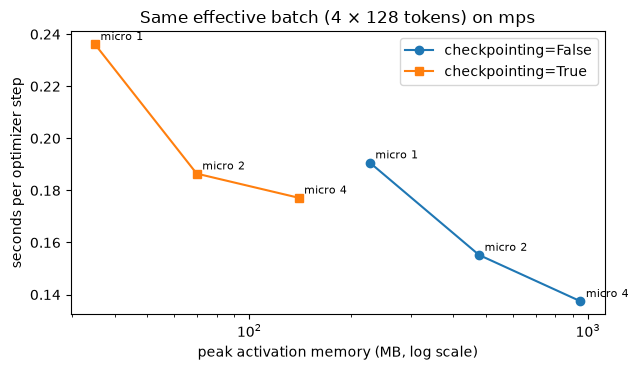

Computed conclusions from the measurements:
1. Micro-batch 1 with 4 accumulation steps (instead of one micro-batch of 4) cut peak activation memory 4.2× and changed step time +39%.
2. Checkpointing at micro-batch 4 cut memory 6.8× for +29% time.
3. Lowest memory: micro 1, checkpointing=True (35 MB); highest throughput: micro 4, checkpointing=False (3725 tokens/s).
4. With a budget of 237 MB (¼ of the no-trick peak), the fastest option is micro 4 with checkpointing=True at 2890 tokens/s.
5. Largest relative gradient difference vs one micro-batch of 4: 8.7e-05 — accumulation reproduced the single-micro-batch gradient up to float32 rounding.


In [43]:
if measure_table is not None:
    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    for ckpt, marker in [(False, "o"), (True, "s")]:
        part = measure_table[measure_table.checkpointing == ckpt]
        ax.plot(part.peak_activation_MB, part.seconds_per_step, marker=marker, ls="-", label=f"checkpointing={ckpt}")
        for _, r in part.iterrows():
            ax.annotate(f"micro {r.micro_batch}", (r.peak_activation_MB, r.seconds_per_step), fontsize=8, xytext=(4, 3), textcoords="offset points")
    ax.set(xscale="log", xlabel="peak activation memory (MB, log scale)", ylabel="seconds per optimizer step",
           title=f"Same effective batch ({EFFECTIVE_BATCH} × {SEQ_REAL} tokens) on {DEVICE}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    base_row = measure_table[(measure_table.micro_batch == EFFECTIVE_BATCH) & (~measure_table.checkpointing)].iloc[0]
    smallest = measure_table.loc[measure_table.peak_activation_MB.idxmin()]
    fastest = measure_table.loc[measure_table.tokens_per_s.idxmax()]
    micro1 = measure_table[(measure_table.micro_batch == 1) & (~measure_table.checkpointing)].iloc[0]
    ckpt8 = measure_table[(measure_table.micro_batch == EFFECTIVE_BATCH) & (measure_table.checkpointing)].iloc[0]
    budget_mb = base_row.peak_activation_MB / 4
    within = measure_table[measure_table.peak_activation_MB <= budget_mb]
    best_within = within.loc[within.tokens_per_s.idxmax()] if len(within) else None
    print("Computed conclusions from the measurements:")
    print(f"1. Micro-batch 1 with {EFFECTIVE_BATCH} accumulation steps (instead of one micro-batch of {EFFECTIVE_BATCH}) cut peak activation memory {base_row.peak_activation_MB / micro1.peak_activation_MB:.1f}× "
          f"and changed step time {micro1.seconds_per_step / base_row.seconds_per_step - 1:+.0%}.")
    ckpt_overhead = ckpt8.seconds_per_step / base_row.seconds_per_step - 1
    print(f"2. Checkpointing at micro-batch {EFFECTIVE_BATCH} cut memory {base_row.peak_activation_MB / ckpt8.peak_activation_MB:.1f}× "
          + (f"for {ckpt_overhead:+.0%} time." if ckpt_overhead > 0.05 else
             f"with no measurable slowdown in this run ({ckpt_overhead:+.0%}; laptop timings are noisy)."))
    print(f"3. Lowest memory: micro {int(smallest.micro_batch)}, checkpointing={smallest.checkpointing} "
          f"({smallest.peak_activation_MB:.0f} MB); highest throughput: micro {int(fastest.micro_batch)}, checkpointing={fastest.checkpointing} "
          f"({fastest.tokens_per_s:.0f} tokens/s).")
    if best_within is not None:
        print(f"4. With a budget of {budget_mb:.0f} MB (¼ of the no-trick peak), the fastest option is micro {int(best_within.micro_batch)} with "
              f"checkpointing={best_within.checkpointing} at {best_within.tokens_per_s:.0f} tokens/s.")
    print(f"5. Largest relative gradient difference vs one micro-batch of {EFFECTIVE_BATCH}: {measure_table.grad_rel_diff_vs_one_batch.max():.1e} "
          "— accumulation reproduced the single-micro-batch gradient up to float32 rounding.")
    del lm
    free_memory()

**Stretch goals**

1. **Add CPU offload** to the planner: ZeRO-Offload keeps bf16 parameters on the GPU and moves gradients and optimizer states to CPU memory — add a row that requires enough host RAM and re-run the table.
2. **Tensor parallelism:** extend `plan_training` with a TP degree (params, gradients, and activations inside TP regions divided by TP) and find the smallest TP that makes 70B full fine-tuning fit on 8 × 80 GB with ZeRO-3.
3. **Throughput:** combine Section 1's 6·N·D with Section 9's all-reduce time to estimate days and communication share for each feasible row.
4. **Measure on a GPU:** run Step 3 on a CUDA machine with `torch.cuda.max_memory_allocated()` and bf16 autocast; compare the ratios with this laptop's.
5. **Validate the activation formula:** measure SmolLM2's activations at several sequence lengths and fit the per-token constant.

### 🗣️ How to talk about this in an interview
- "Before requesting GPUs I estimate memory **per GPU**: 16 bytes/param for mixed-precision Adam divided by the ZeRO sharding factor, plus checkpointed activations that scale with sequence × hidden × layers, plus 10% headroom."
- "I encoded that as a planner that picks the least-communicating strategy that fits — DDP, ZeRO-1, ZeRO-2, then ZeRO-3 — and showed why summing memory across GPUs gives wrong answers."
- "For 7B/13B/70B on six GPU layouts, the table shows where full fine-tuning becomes feasible and where LoRA or QLoRA is the realistic option."
- "I validated the trade-offs on a real model: accumulation and checkpointing each cut activation memory several-fold at a measured time cost, and accumulated gradients matched the big batch."
- "I checked the ZeRO formulas against the paper's published 7.5B/64-GPU numbers and ran real DDP and FSDP2 jobs to confirm replicas stay in sync."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. How much GPU memory does full fine-tuning of a 7B model need?**

<details><summary>Show answer</summary>

- **30-second answer:** Model states: 16 bytes/param with mixed-precision AdamW — 2 (bf16 weights) + 2 (grads) + 4 (fp32 master) + 4 + 4 (Adam moments) — so ~112 GB, plus activations (GBs per sequence at 4K tokens even with checkpointing) and ~10% overhead. It needs sharding (ZeRO-2/3, FSDP) across GPUs, offloading, or a cheaper recipe (LoRA/QLoRA, 8-bit Adam).
- **Go deeper:** Inference needs only ~14 GB (bf16 weights) plus KV cache. 8-bit Adam cuts optimizer states from 8 to ~2 bytes; ZeRO-3 divides the 16 bytes by the number of GPUs.
- **❌ Common wrong answer:** "14 GB, because the model is 7B × 2 bytes" or "84 GB" (12 bytes, forgetting the master weights).

</details>

**Q2. Why keep fp32 master weights in mixed-precision training, and does mixed precision save memory?**

<details><summary>Show answer</summary>

- **30-second answer:** Updates (learning rate × gradient) are often smaller than 16-bit formats can represent next to the weight value, so they'd round to zero; the optimizer updates an fp32 copy and casts it back to 16-bit for compute. So model-state memory stays ~16 bytes/param; the savings are in **activations** (16-bit) and speed.
- **Go deeper:** fp16 also needs dynamic loss scaling to keep small gradients from underflowing; bf16 has fp32's range and doesn't. Pure-bf16 training without master weights exists (with stochastic rounding or careful optimizers) but is riskier.
- **❌ Common wrong answer:** "Mixed precision halves training memory."

</details>

**Q3. What does gradient checkpointing trade, and when do you use it?**

<details><summary>Show answer</summary>

- **30-second answer:** It stores only selected activations (usually each block's input) and recomputes the rest during backward: large activation-memory savings for roughly one extra forward pass (~20–40% slower). Use it when activations — long sequences, big micro-batches — are what doesn't fit.
- **Go deeper:** Chen et al. (2016) showed O(√n) memory for n layers with a √n checkpoint spacing. Selective recomputation (Korthikanti et al., 2022) recomputes only cheap-to-recompute, memory-heavy parts like attention. It doesn't reduce model-state memory.
- **❌ Common wrong answer:** "It saves the model weights to disk periodically" (that's checkpointing the *training state*, a different thing).

</details>

**Q4. Is gradient accumulation exactly equivalent to a larger batch?**

<details><summary>Show answer</summary>

- **30-second answer:** For the gradient, yes — if each micro-batch loss is weighted by its share of the total examples (or tokens). This notebook asserted equality to 1e-12. The optimizer sees one step with the summed gradient.
- **Go deeper:** Breaks with unequal micro-batch sizes and "mean of means" (normalize by total tokens — `num_items_in_batch`), with BatchNorm, and in DDP you should wrap non-final micro-steps in `no_sync()` to avoid wasted all-reduces. It trades time for memory; it doesn't speed anything up.
- **❌ Common wrong answer:** "It's the same but you must multiply the learning rate by the number of steps."

</details>

**Q5. Compare DDP, ZeRO, and FSDP.**

<details><summary>Show answer</summary>

- **30-second answer:** DDP replicates everything on each GPU and all-reduces gradients — simple and fast, but no memory savings. ZeRO shards optimizer states (1), gradients (2), and parameters (3) across data-parallel ranks. FSDP is PyTorch's native ZeRO-3-style implementation: all-gather each wrapped unit's parameters for forward/backward, reduce-scatter gradients, shard optimizer states.
- **Go deeper:** FSDP2 (`fully_shard`) shards per parameter as DTensors, composes with tensor parallelism and `torch.compile`; `reshard_after_forward=False` is ZeRO-2-like. DeepSpeed adds offload to CPU/NVMe and a config-driven engine. Choose the least sharding that fits, because sharding adds communication.
- **❌ Common wrong answer:** "FSDP is model parallelism" — each rank still runs the full layer computation on its own batch.

</details>

**Q6. Give the ZeRO per-GPU memory formulas and their communication cost.**

<details><summary>Show answer</summary>

- **30-second answer:** With K = 12: DDP (4 + K)Ψ; ZeRO-1 4Ψ + KΨ/N; ZeRO-2 2Ψ + (2 + K)Ψ/N; ZeRO-3 (4 + K)Ψ/N. For 7.5B on 64 GPUs: 120, 31.4, 16.6, 1.9 GB. Stages 1–2 keep DDP's 2Ψ communication; stage 3 needs ~3Ψ (1.5×).
- **Go deeper:** ZeRO-1/2 memory flattens at 4×/8× savings; only ZeRO-3 scales with N. Activations and temporary buffers are separate (ZeRO-R).
- **❌ Common wrong answer:** "ZeRO-3 gives 64× savings on 8 GPUs."

</details>

**Q7. Tensor vs pipeline vs data parallelism — how do you combine them?**

<details><summary>Show answer</summary>

- **30-second answer:** TP splits matrices inside a layer and all-reduces every layer — keep it inside a node on NVLink. PP splits layers into stages and passes activations between neighbours — use it across nodes, and reduce the bubble (p−1)/(m+p−1) with more micro-batches. DP/ZeRO replicates or shards the whole pipeline for throughput. World size = TP × PP × DP.
- **Go deeper:** Sequence parallelism shards LayerNorm/dropout activations along the sequence in TP regions; context parallelism (Ring Attention, Ulysses) shards the sequence itself for long contexts; expert parallelism places MoE experts on different GPUs with all-to-all.
- **❌ Common wrong answer:** "Pipeline parallelism has no idle time."

</details>

**Q8. How does ring all-reduce work and what does it cost?**

<details><summary>Show answer</summary>

- **30-second answer:** Split the tensor into N chunks; reduce-scatter for N−1 steps (send a chunk right, add what arrives from the left), then all-gather for N−1 steps. Each GPU sends 2(N−1)/N × the message size — about 2×, independent of N — in 2(N−1) steps.
- **Go deeper:** Bandwidth-optimal but latency grows with N; NCCL also uses tree algorithms. Time ≈ 2(N−1)/N · S / bandwidth + 2(N−1)·latency. DDP buckets gradients (25 MB default) and overlaps communication with backward.
- **❌ Common wrong answer:** "Each GPU sends its gradient to every other GPU" (that's N−1 × size).

</details>

### 💻 Coding

**Q9. Sketch a correct multi-GPU DDP training script.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  dist.init_process_group("nccl"); local_rank = int(os.environ["LOCAL_RANK"]); torch.cuda.set_device(local_rank)
  model = DDP(Model().cuda(), device_ids=[local_rank])
  sampler = DistributedSampler(dataset, shuffle=True); loader = DataLoader(dataset, batch_size=B, sampler=sampler)
  for epoch in range(E):
      sampler.set_epoch(epoch)
      for step, batch in enumerate(loader):
          ctx = model.no_sync() if (step + 1) % accum else contextlib.nullcontext()
          with ctx: (loss_fn(model(batch)) / accum).backward()
          if (step + 1) % accum == 0: opt.step(); opt.zero_grad()
      if dist.get_rank() == 0: torch.save(model.module.state_dict(), "ckpt.pt")
  dist.destroy_process_group()
  ```
  Launch with `torchrun --nproc_per_node 8 train.py`.
- **Go deeper:** Same seed for model init on all ranks (or broadcast), all ranks must call the same collectives in the same order, save on rank 0 only, use `model.module` for the underlying model.
- **❌ Common wrong answer:** Forgetting `set_device` (all ranks pile onto GPU 0), `set_epoch`, or saving from every rank at once.

</details>

**Q10. Compute the per-GPU memory for a given model and cluster and recommend a strategy.**

<details><summary>Show answer</summary>

- **30-second answer:** For each strategy, per-GPU need = ZeRO formula for its stage + activations per GPU; compare with usable memory per GPU (minus headroom); pick the first that fits in the order DDP → ZeRO-1 → ZeRO-2 → ZeRO-3 → offload/TP. Example: 7B on 8 × 40 GB with 4 GB activations → ZeRO-2 (30.3 GB), because ZeRO-1 needs 42.5 GB per GPU.
- **Go deeper:** Include micro-batch/sequence assumptions, gradient checkpointing, 8-bit optimizers, and CPU RAM for offload. See `plan_training` in Build It From Scratch.
- **❌ Common wrong answer:** Comparing total model memory with the sum of all GPUs' memory.

</details>

### 🐛 Debugging Scenarios

**Q11. A distributed job hangs forever at the same step. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Mismatched collectives — some ranks call an all-reduce/all-gather that others skip (e.g. evaluation or logging with a collective only on rank 0, uneven numbers of batches per rank, a data-dependent `if`). Set a process-group timeout, enable `TORCH_DISTRIBUTED_DEBUG=DETAIL` / `NCCL_DEBUG=INFO`, and dump stack traces from every rank.
- **Go deeper:** Use `drop_last=True` or `Join` for uneven inputs, make every rank run the same code path, and check networking (firewalls, wrong interface via `NCCL_SOCKET_IFNAME`). FSDP hangs also come from different wrapping or parameter orders across ranks.
- **❌ Common wrong answer:** "Increase the batch size" or "it's a GPU driver bug" without checking collective order.

</details>

**Q12. Training on 8 GPUs gives a different loss curve than on 1 GPU. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** The global batch changed (micro × accumulation × world) but the learning rate and warmup didn't; the sampler shards/shuffles differently (missing `set_epoch`); loss normalization differs across ranks (per-rank mean with different token counts); or dropout/data-order RNG differs. With the same global batch, data order, and normalization, curves should match — as this notebook's DDP check showed exactly.
- **Go deeper:** Keep the global batch fixed by adjusting accumulation when the GPU count changes; normalize by the global number of tokens; check BatchNorm (use SyncBatchNorm or avoid it).
- **❌ Common wrong answer:** "Distributed training is inherently non-deterministic, ignore it."

</details>

**Q13. Only rank 0 runs out of memory. What's going on?**

<details><summary>Show answer</summary>

- **30-second answer:** Rank 0 does extra work — gathering a full state dict for checkpoints, running evaluation, logging tensors — or other ranks created CUDA contexts on GPU 0 because they never called `torch.cuda.set_device(local_rank)` (or loaded checkpoints with `map_location` pointing at GPU 0).
- **Go deeper:** Use sharded checkpoints (`torch.distributed.checkpoint`) or gather to CPU with offload; set the device before creating tensors; check `nvidia-smi` for multiple processes on GPU 0.
- **❌ Common wrong answer:** "Rank 0's batch is bigger" — the sampler gives equal shards.

</details>

### 🏗️ Design

**Q14. Plan fine-tuning a 70B model for a company with 16 × 80 GB GPUs across two nodes.**

<details><summary>Show answer</summary>

- **30-second answer:** First ask whether LoRA suffices. Full fine-tuning: 1,120 GB model states → FSDP/ZeRO-3 over 16 GPUs = 70 GB/GPU of states alone, too tight with activations → add CPU optimizer offload or tensor parallelism within each node (TP = 8 over NVLink, FSDP across nodes), gradient checkpointing, FlashAttention, micro-batch 1 with accumulation to the target global batch. LoRA: ~140 GB bf16 base sharded with FSDP (~9 GB/GPU) — comfortable, far cheaper. QLoRA: ~36 GB base, fits on single GPUs for experiments.
- **Go deeper:** Validate on 2 GPUs first (same global batch → same loss), measure MFU and all-reduce time, use sharded checkpoints every N minutes, and budget days = 6·N·D / (GPUs × FLOPs/s × MFU).
- **❌ Common wrong answer:** "Use DDP on the 16 GPUs" (each GPU would need 1,120 GB).

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** Per-GPU model states for a 7.5B model with ZeRO-3 on 8 GPUs (16 bytes/param)?
<details><summary>Answer</summary>

`15 GB` = 120 GB / 8.
</details>

**2.** In a ring all-reduce with **2** GPUs, how many bytes does each GPU send for a 10 GB gradient?
<details><summary>Answer</summary>

`10 GB` = 2 × (2 − 1)/2 × 10 GB.
</details>

**3.** `train_micro_batch_size_per_gpu = 2`, `gradient_accumulation_steps = 4`, 8 GPUs — what must `train_batch_size` be?
<details><summary>Answer</summary>

`64`.
</details>

**4.** Pipeline bubble fraction with 2 stages and 1 micro-batch?
<details><summary>Answer</summary>

`0.5` = (2 − 1)/(1 + 2 − 1) — each stage idles half the time.
</details>

**5.** True or false: mixed-precision Adam needs 12 bytes per parameter because weights are stored in 16-bit.
<details><summary>Answer</summary>

**False** — 16 bytes: 2 + 2 + 4 (fp32 master) + 4 + 4.
</details>

## 📚 Resources

### 📖 Official Docs
- [PyTorch — Getting Started with Distributed Data Parallel](https://docs.pytorch.org/tutorials/intermediate/ddp_tutorial.html)
- [PyTorch — Getting Started with Fully Sharded Data Parallel (FSDP2)](https://docs.pytorch.org/tutorials/intermediate/FSDP_tutorial.html)
- [PyTorch — torchrun (Elastic Launch)](https://docs.pytorch.org/docs/2.14/elastic/run.html)
- [DeepSpeed — Configuration JSON](https://www.deepspeed.ai/docs/config-json/) and [ZeRO tutorial](https://www.deepspeed.ai/tutorials/zero/)
- [Hugging Face Accelerate — FSDP guide](https://huggingface.co/docs/accelerate/usage_guides/fsdp)

### 🎥 Videos
- [Umar Jamil — Distributed Data Parallel (DDP) with PyTorch: complete tutorial with cloud infrastructure and code](https://www.youtube.com/watch?v=toUSzwR0EV8) (1 h 12 min) — data vs model parallelism, DDP internals, and gradient accumulation, then a real multi-GPU run
- [Ahmed Taha — How Fully Sharded Data Parallel (FSDP) works?](https://www.youtube.com/watch?v=By_O0k102PY) (33 min) — a visual walk-through of DDP vs FSDP's all-gather and reduce-scatter

### 📄 Papers
- [Rajbhandari et al. (2019) — ZeRO: Memory Optimizations Toward Training Trillion Parameter Models](https://arxiv.org/abs/1910.02054)
- [Ren et al. (2021) — ZeRO-Offload](https://arxiv.org/abs/2101.06840) · [Rajbhandari et al. (2021) — ZeRO-Infinity](https://arxiv.org/abs/2104.07857)
- [Zhao et al. (2023) — PyTorch FSDP: Experiences on Scaling Fully Sharded Data Parallel](https://arxiv.org/abs/2304.11277)
- [Li et al. (2020) — PyTorch Distributed: Experiences on Accelerating Data Parallel Training](https://arxiv.org/abs/2006.15704)
- [Shoeybi et al. (2019) — Megatron-LM](https://arxiv.org/abs/1909.08053) · [Narayanan et al. (2021) — Efficient Large-Scale Language Model Training on GPU Clusters Using Megatron-LM](https://arxiv.org/abs/2104.04473)
- [Huang et al. (2018) — GPipe](https://arxiv.org/abs/1811.06965)
- [Chen et al. (2016) — Training Deep Nets with Sublinear Memory Cost](https://arxiv.org/abs/1604.06174) · [Korthikanti et al. (2022) — Reducing Activation Recomputation in Large Transformer Models](https://arxiv.org/abs/2205.05198)
- [Micikevicius et al. (2017) — Mixed Precision Training](https://arxiv.org/abs/1710.03740)
- [Kaplan et al. (2020) — Scaling Laws for Neural Language Models](https://arxiv.org/abs/2001.08361) (C ≈ 6ND)
- [Liu et al. (2023) — Ring Attention with Blockwise Transformers](https://arxiv.org/abs/2310.01889)

### 📘 Books & Courses
- [Hugging Face — The Ultra-Scale Playbook](https://huggingface.co/spaces/nanotron/ultrascale-playbook) — free, interactive book on DP, ZeRO, TP, PP, CP with measurements
- [Stas Bekman — Machine Learning Engineering Open Book](https://github.com/stas00/ml-engineering) — practical guide to training at scale, debugging hangs, and hardware

### 🏋️ Practice
- [pytorch/examples — distributed](https://github.com/pytorch/examples/tree/main/distributed) — runnable DDP, FSDP, TP, and PP examples
- [pytorch/torchtitan](https://github.com/pytorch/torchtitan) — a clean reference for FSDP2 + TP + PP LLM pretraining
- [huggingface/nanotron](https://github.com/huggingface/nanotron) — minimal 3D-parallel training library to read and modify

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Training compute | how long it takes | C ≈ 6·N·D FLOPs; days = C / (GPUs × FLOPs/s × MFU) / 86,400 |
| Model states | memory per parameter | mixed-precision Adam: 2 + 2 + 4 + 4 + 4 = **16 bytes** (not 12) |
| Activations | memory per token | ∝ batch × seq × hidden × layers; GPT-2 rule ≈ 12·h·b·s·L values |
| Gradient checkpointing | recompute instead of store | `model.gradient_checkpointing_enable()`; ~one extra forward |
| Gradient accumulation | big batch in small pieces | loss / steps per micro-batch; `no_sync()` in DDP; global batch = micro × accum × world |
| DDP | replicate + all-reduce grads | `init_process_group`, `DistributedSampler` + `set_epoch`, `DDP(model)`, `torchrun --nproc_per_node` |
| ZeRO-1/2/3 | shard states per GPU | 4Ψ + 12Ψ/N · 2Ψ + 14Ψ/N · 16Ψ/N bytes; comm 2Ψ, 2Ψ, 3Ψ |
| FSDP2 | PyTorch ZeRO-3 | `fully_shard(block)`, then `fully_shard(model)`; `reshard_after_forward`, `MixedPrecisionPolicy`, `CPUOffloadPolicy` |
| Tensor / pipeline / context parallel | split the model or sequence | TP inside a node; PP bubble (p − 1)/(m + p − 1); CP/Ring Attention for long sequences |
| Ring all-reduce | bandwidth-optimal sync | reduce-scatter + all-gather; 2(N − 1)/N × size per GPU |
| DeepSpeed config | ZeRO via JSON | `train_batch_size = micro × accum × world`; `zero_optimization.stage`; launch with `deepspeed`/`torchrun` |
| Planning | pick a strategy | per-GPU need vs usable memory; DDP → ZeRO-1 → ZeRO-2 → ZeRO-3 → offload/TP/PP; or LoRA/QLoRA |

## ➡️ What's Next

**[09 MLOps · MLflow](../09_MLOps/01_MLflow.ipynb)** — whether a run takes one GPU or a hundred, you need to track its parameters, metrics, and artifacts and version the resulting models; MLflow is where that starts.